In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

#from sklearn.preprocessing import StandardScaler

#import random
#from datetime import datetime
#from scipy.stats import skewnorm
#from IPython.display import clear_output
import re

#import ipycytoscape
#import torch

#from pyvis.network import Network
#import os

from node2vec import Node2Vec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader,TensorDataset, Subset

from random import randint



DEBUG = True
RAW_DATA_PATH = 'Sim_Raw_data.parquet'
SAVE_PATH_0 = "GMAN_model_zero.pth"
SAVE_PATH_1 = "GMAN_model_att_spatial.pth"
SAVE_PATH_2 = "GMAN_model_phy_loss.pth"
SAMPLING = '1h'

## INPUT DATA

In [3]:
RAW_DATA = pd.read_parquet(RAW_DATA_PATH)
RAW_DATA

2024-01-01 00:00:00  2024-01-01 01:00:00  2024-01-01 02:00:00  \
0    1                                                                     
HR_A MR_A             0.242307             0.652708             0.304576   
MR_A C                0.478030             1.269975             0.561737   
HR_B MR_B             1.709748             1.821457             1.770315   
MR_B MR_A             0.211877             0.559376             0.361619   
     A                1.420262             1.711117             1.377888   
C    D                0.298330             0.363194             0.086251   
     S7               0.158308             0.634294             0.643398   
D    E                0.119302             0.456115             0.000000   
     S6               0.087604             0.000000             0.000000   
     S5               0.298784             0.372956             0.218950   
A    B                0.360531             0.454418             0.116136   
     S1               0.138936             0.000000             0.000000   
     S2               1.260369             1.025618             1.290493   
B    D                0.310024             0.418048             0.084145   
     S3               0.096375             0.000000             0.000000   
E    S4               0.126457             0.414049             0.000000   

           2024-01-01 03:00:00  2024-01-01 04:00:00  2024-01-01 05:00:00  \
0    1                                                                     
HR_A MR_A             0.728600             1.952172             3.024958   
MR_A C                1.357907             3.936300             6.132805   
HR_B MR_B             2.769749             8.361131             8.582184   
MR_B MR_A             0.529233             1.754704             2.239559   
     A                2.584300             6.535277             9.010119   
C    D                1.027335             1.763683             2.050956   
     S7               0.426665             2.564478             4.264953   
D    E                0.880936             1.186638             1.483351   
     S6               0.000000             0.293015             0.488143   
     S5               0.947753             1.927081             2.641454   
A    B                1.300219             2.133810             3.893518   
     S1               0.000000             0.357088             0.480139   
     S2               0.980038             3.675115             4.695258   
B    D                0.813502             1.942203             1.977367   
     S3               0.318854             0.725013             1.528340   
E    S4               0.698429             1.212364             1.262769   

           2024-01-01 06:00:00  2024-01-01 07:00:00  2024-01-01 08:00:00  \
0    1                                                                     
HR_A MR_A             6.361310             8.542597            10.155390   
MR_A C               10.018637            15.815668            25.137249   
HR_B MR_B            21.891609            28.852560            54.076035   
MR_B MR_A             5.541901             7.716193            13.547432   
     A               14.057184            21.184876            43.401270   
C    D                4.588321             6.742612            10.141587   
     S7               6.348620             6.937130            11.267387   
D    E                3.650932             5.620261             8.168845   
     S6               0.574270             1.750391             1.086411   
     S5               3.898288            10.334808            13.248105   
A    B                5.586427            10.878161            16.600997   
     S1               1.004884             0.949194             2.843370   
     S2              10.220297            13.312700            18.101456   
B    D                3.648788             8.229116            10.381166   
     S3               1.674755             3.340571      

## ADJENCY and INCIDENCE MATRIX

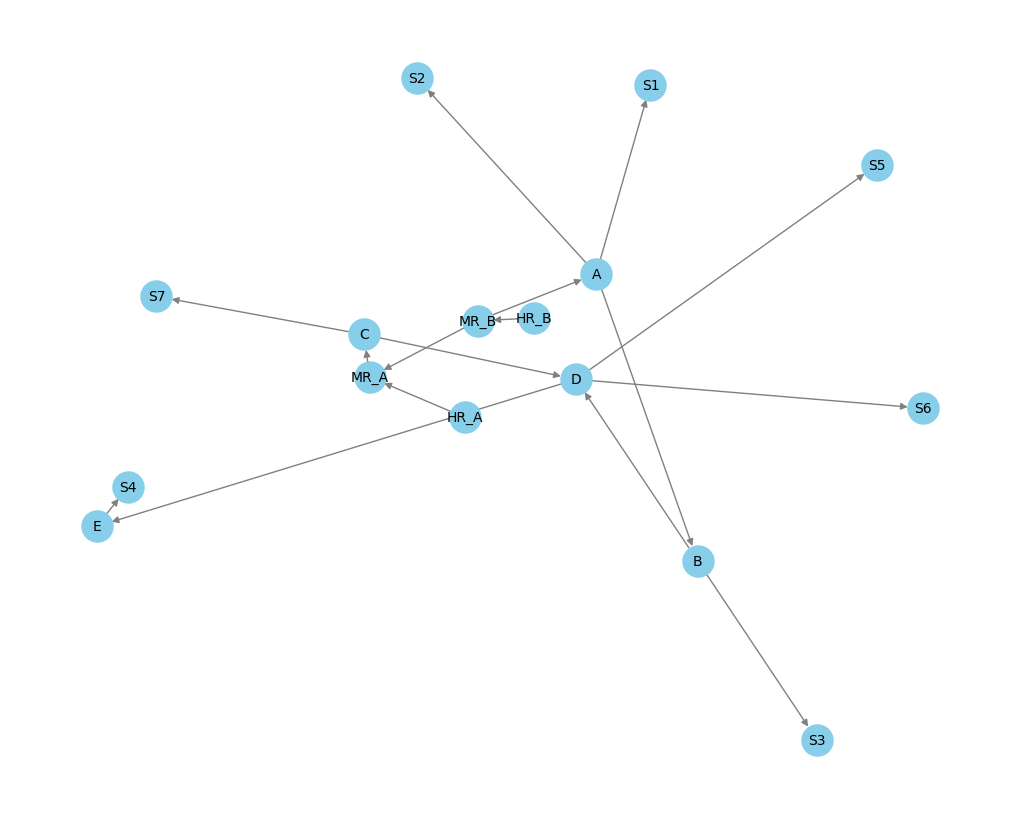

In [4]:
G_phy = nx.DiGraph()
for edge in RAW_DATA.T.columns:
    G_phy.add_edge(edge[0], edge[1])



plt.figure(figsize=(10, 8))
nx.draw(G_phy, with_labels=True, node_color='skyblue', edge_color='gray', node_size=500, font_size=10)
plt.show()


In [147]:
def get_flow_metadata(G):
    """
    G: The original Physical Graph (nx.DiGraph)
    Returns:
        - edges: List of physical edges in fixed order
        - incidence_matrix: Full [Nodes x Edges] matrix
        - adjacency_matrix: [Edges x Edges] line graph adjacency
        - internal_nodes_mask: Boolean tensor for junctions (In & Out > 0)
    """
    # 1. Standardize Edge and Node Ordering
    edges = list(G.edges())
    nodes = list(G.nodes())
    edge_to_idx = {e: i for i, e in enumerate(edges)}
    
    # 2. Build FULL Incidence Matrix (Physical Graph)
    # Shape: (Num_Nodes, Num_Edges)
    full_inc_mat = np.zeros((len(nodes), len(edges)))
    
    for j, (u, v) in enumerate(edges):
        # -1 for source of the edge, +1 for target of the edge
        u_idx, v_idx = nodes.index(u), nodes.index(v)
        full_inc_mat[u_idx, j] = -1  # Outflow from node u
        full_inc_mat[v_idx, j] = 1   # Inflow to node v
    
    # 3. Identify Internal Nodes (Junctions)
    # A node is internal if it has at least one incoming and one outgoing edge
    in_degrees = dict(G.in_degree())
    out_degrees = dict(G.out_degree())
    
    internal_mask = []
    for node in nodes:
        is_internal = in_degrees[node] > 0 and out_degrees[node] > 0
        internal_mask.append(is_internal)
    
    internal_mask_tensor = torch.BoolTensor(internal_mask)

    # 4. Build Adjacency Matrix for the Line Graph (for GNN message passing)
    num_edges = len(edges)
    adj_mat = np.zeros((num_edges, num_edges))
    
    L = nx.line_graph(G)
    for u, v in L.edges():
        idx_u, idx_v = edge_to_idx[u], edge_to_idx[v]
        adj_mat[idx_u, idx_v] = 1
        #adj_mat[idx_v, idx_u] = 1  # Standard for GNNs
        
    return {
        "edges": edges,
        "nodes": nodes,
        "incidence_matrix": torch.FloatTensor(full_inc_mat),
        "adjacency_matrix": torch.FloatTensor(adj_mat),
        "internal_nodes_mask": internal_mask_tensor
    }

def get_leaf_mask(G_physical):
    """
    G_physical: The original Physical Graph (nx.DiGraph)
    Returns: A boolean tensor where True = Leaf Edge
    """
    edges = list(G_physical.edges())
    leaf_mask = []
    
    for (u, v) in edges:
        # A simple heuristic for a leaf edge:
        # It connects to a 'source' (in_degree 0) 
        # OR it connects to a 'sink' (out_degree 0)
        is_source_edge = G_physical.in_degree(u) == 0
        is_sink_edge = G_physical.out_degree(v) == 0
        
        leaf_mask.append(is_source_edge or is_sink_edge)
        
    return torch.BoolTensor(leaf_mask)

G_DATA = get_flow_metadata(G_phy)

EDGES = G_DATA['edges']
NODES = G_DATA['nodes']

ADJ_MATRIX = G_DATA['adjacency_matrix']
ADJ_MATRIX_DF = pd.DataFrame(ADJ_MATRIX, columns=pd.MultiIndex.from_tuples(EDGES), index=pd.MultiIndex.from_tuples(EDGES))

ATT_MATRIX = np.where((ADJ_MATRIX +np.eye(len(EDGES))) == 0, -np.inf, 0.0)
ATT_MATRIX_DF = pd.DataFrame(ATT_MATRIX, columns=pd.MultiIndex.from_tuples(EDGES), index=pd.MultiIndex.from_tuples(EDGES))

INC_MATRIX = G_DATA['incidence_matrix']
INC_MATRIX_DF = pd.DataFrame(INC_MATRIX, columns=pd.MultiIndex.from_tuples(EDGES), index=NODES)
LEAF_MASK = get_leaf_mask(G_phy)

print("Adjacency Matrix")
display(ADJ_MATRIX_DF)

print("Attention Matrix")
display(ATT_MATRIX_DF)

print("Incidence Matrix")
display(INC_MATRIX_DF)

Adjacency Matrix


HR_A MR_A    C      HR_B MR_B         A              D            \
          MR_A    C    D   S7 MR_B MR_A    A    B   S1   S2    E   S6   S5   
HR_A MR_A  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
MR_A C     0.0  0.0  1.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
C    D     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0   
     S7    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
HR_B MR_B  0.0  0.0  0.0  0.0  0.0  1.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0   
MR_B MR_A  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
     A     0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0  0.0  0.0  0.0   
A    B     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
     S1    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
     S2    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
D    E     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
     S6    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
     S5    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
E    S4    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
B    D     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0   
     S3    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

             E    B       
            S4    D   S3  
HR_A MR_A  0.0  0.0  0.0  
MR_A C     0.0  0.0  0.0  
C    D     0.0  0.0  0.0  
     S7    0.0  0.0  0.0  
HR_B MR_B  0.0  0.0  0.0  
MR_B MR_A  0.0  0.0  0.0  
     A     0.0  0.0  0.0  
A    B     0.0  1.0  1.0  
     S1    0.0  0.0  0.0  
     S2    0.0  0.0  0.0  
D    E     1.0  0.0  0.0  
     S6    0.0  0.0  0.0  
     S5    0.0  0.0  0.0  
E    S4    0.0  0.0  0.0  
B    D     0.0  0.0  0.0  
     S3    0.0  0.0  0.0

Attention Matrix


HR_A MR_A    C      HR_B MR_B         A              D            \
          MR_A    C    D   S7 MR_B MR_A    A    B   S1   S2    E   S6   S5   
HR_A MR_A  0.0  0.0 -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf   
MR_A C    -inf  0.0  0.0  0.0 -inf -inf -inf -inf -inf -inf -inf -inf -inf   
C    D    -inf -inf  0.0 -inf -inf -inf -inf -inf -inf -inf  0.0  0.0  0.0   
     S7   -inf -inf -inf  0.0 -inf -inf -inf -inf -inf -inf -inf -inf -inf   
HR_B MR_B -inf -inf -inf -inf  0.0  0.0  0.0 -inf -inf -inf -inf -inf -inf   
MR_B MR_A -inf  0.0 -inf -inf -inf  0.0 -inf -inf -inf -inf -inf -inf -inf   
     A    -inf -inf -inf -inf -inf -inf  0.0  0.0  0.0  0.0 -inf -inf -inf   
A    B    -inf -inf -inf -inf -inf -inf -inf  0.0 -inf -inf -inf -inf -inf   
     S1   -inf -inf -inf -inf -inf -inf -inf -inf  0.0 -inf -inf -inf -inf   
     S2   -inf -inf -inf -inf -inf -inf -inf -inf -inf  0.0 -inf -inf -inf   
D    E    -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf  0.0 -inf -inf   
     S6   -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf  0.0 -inf   
     S5   -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf  0.0   
E    S4   -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf   
B    D    -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf  0.0  0.0  0.0   
     S3   -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf   

             E    B       
            S4    D   S3  
HR_A MR_A -inf -inf -inf  
MR_A C    -inf -inf -inf  
C    D    -inf -inf -inf  
     S7   -inf -inf -inf  
HR_B MR_B -inf -inf -inf  
MR_B MR_A -inf -inf -inf  
     A    -inf -inf -inf  
A    B    -inf  0.0  0.0  
     S1   -inf -inf -inf  
     S2   -inf -inf -inf  
D    E     0.0 -inf -inf  
     S6   -inf -inf -inf  
     S5   -inf -inf -inf  
E    S4    0.0 -inf -inf  
B    D    -inf  0.0 -inf  
     S3   -inf -inf  0.0

Incidence Matrix


HR_A MR_A    C      HR_B MR_B         A              D              E  \
     MR_A    C    D   S7 MR_B MR_A    A    B   S1   S2    E   S6   S5   S4   
HR_A -1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
MR_A  1.0 -1.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
C     0.0  1.0 -1.0 -1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
HR_B  0.0  0.0  0.0  0.0 -1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
MR_B  0.0  0.0  0.0  0.0  1.0 -1.0 -1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
A     0.0  0.0  0.0  0.0  0.0  0.0  1.0 -1.0 -1.0 -1.0  0.0  0.0  0.0  0.0   
D     0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0 -1.0 -1.0 -1.0  0.0   
S7    0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
E     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0 -1.0   
S6    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0   
S5    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0   
B     0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0   
S1    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0   
S2    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0   
S3    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
S4    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0   

        B       
        D   S3  
HR_A  0.0  0.0  
MR_A  0.0  0.0  
C     0.0  0.0  
HR_B  0.0  0.0  
MR_B  0.0  0.0  
A     0.0  0.0  
D     1.0  0.0  
S7    0.0  0.0  
E     0.0  0.0  
S6    0.0  0.0  
S5    0.0  0.0  
B    -1.0 -1.0  
S1    0.0  0.0  
S2    0.0  0.0  
S3    0.0  1.0  
S4    0.0  0.0

# DATA PREPARATION

In [9]:
DATA_RAW_MODEL = RAW_DATA.T.copy()
DATA_RAW_MODEL = DATA_RAW_MODEL.resample(SAMPLING).mean()

## 8 Months history
DATA_RAW_MODEL = DATA_RAW_MODEL[DATA_RAW_MODEL.index.month.isin(DATA_RAW_MODEL.index.month.unique()[-8:])]
DATA_RAW_MODEL.columns.names = ['from','to']

DATA_RAW_MODEL = DATA_RAW_MODEL[EDGES]
DATA_RAW_MODEL = DATA_RAW_MODEL.round(2)
DATA_RAW_MODEL


from                  HR_A    MR_A      C           HR_B   MR_B          \
to                    MR_A       C      D     S7    MR_B   MR_A       A   
2024-01-01 00:00:00   0.24    0.48   0.30   0.16    1.71   0.21    1.42   
2024-01-01 01:00:00   0.65    1.27   0.36   0.63    1.82   0.56    1.71   
2024-01-01 02:00:00   0.30    0.56   0.09   0.64    1.77   0.36    1.38   
2024-01-01 03:00:00   0.73    1.36   1.03   0.43    2.77   0.53    2.58   
2024-01-01 04:00:00   1.95    3.94   1.76   2.56    8.36   1.75    6.54   
...                    ...     ...    ...    ...     ...    ...     ...   
2024-06-28 19:00:00  67.10  152.94  47.38  73.87  278.75  69.69  164.71   
2024-06-28 20:00:00  46.86   79.85  32.37  67.56  166.57  45.57   87.63   
2024-06-28 21:00:00  29.93   58.71  10.39  38.13   78.97  32.19   50.40   
2024-06-28 22:00:00   8.31   18.10   4.18  18.40   18.45   8.48   13.63   
2024-06-28 23:00:00   1.42    2.86   1.53   1.65    5.21   1.31    3.02   

from                     A                    D                    E      B  \
to                       B     S1     S2      E     S6     S5     S4      D   
2024-01-01 00:00:00   0.36   0.14   1.26   0.12   0.09   0.30   0.13   0.31   
2024-01-01 01:00:00   0.45   0.00   1.03   0.46   0.00   0.37   0.41   0.42   
2024-01-01 02:00:00   0.12   0.00   1.29   0.00   0.00   0.22   0.00   0.08   
2024-01-01 03:00:00   1.30   0.00   0.98   0.88   0.00   0.95   0.70   0.81   
2024-01-01 04:00:00   2.13   0.36   3.68   1.19   0.29   1.93   1.21   1.94   
...                    ...    ...    ...    ...    ...    ...    ...    ...   
2024-06-28 19:00:00  99.47  59.97  39.61  27.10  29.19  60.13  28.52  44.70   
2024-06-28 20:00:00  43.67  37.86  19.85  12.58  11.57  28.97  13.90  25.80   
2024-06-28 21:00:00  17.65  24.27   8.45   6.58   2.81  13.52   5.33   9.34   
2024-06-28 22:00:00   4.73   5.35   2.10   1.71   1.75   5.00   1.67   4.36   
2024-06-28 23:00:00   1.68   1.01   0.78   0.54   0.69   1.20   0.59   1.10   

from                        
to                      S3  
2024-01-01 00:00:00   0.10  
2024-01-01 01:00:00   0.00  
2024-01-01 02:00:00   0.00  
2024-01-01 03:00:00   0.32  
2024-01-01 04:00:00   0.73  
...                    ...  
2024-06-28 19:00:00  41.13  
2024-06-28 20:00:00  16.41  
2024-06-28 21:00:00   4.47  
2024-06-28 22:00:00   2.29  
2024-06-28 23:00:00   0.26  

[4320 rows x 16 columns]

# PARAMETERES

In [82]:
# TRAINING PARAMS
BATCH_SIZE = 32
EPOCHS = 30
LR = 0.001

# DATASET PARAMS
FREQ_H = int(re.search(r'[a-z]*(\d+)[a-z]*', SAMPLING)[1])
FREQ_MINUTES = FREQ_H*60
NUM_NODES = ADJ_MATRIX.shape[0]
HIST_STEPS = int(2*(24/FREQ_H))          # 2 days
PRED_STEPS = int(1*(24/FREQ_H))          # 1 day
INPUT_DIM = 1
OUTPUT_DIM = 1
D_MODEL = 64

STEPS_PER_DAY = int(24/FREQ_H)
DAYS_PER_WEEK = 7
MONTHS_PER_YEAR = 12


TIME_FEATURES = STEPS_PER_DAY + DAYS_PER_WEEK + MONTHS_PER_YEAR 

LAYERS_ENC_DEC = 3
K_HEADS = 4
D_HEAD = int(D_MODEL/K_HEADS)

print(f"Frequency: {FREQ_H} hours")
print(f"Frequency: {FREQ_MINUTES} minutes")
print(f"Number of nodes: {NUM_NODES}")
print(f"Number of historical steps: {HIST_STEPS}")
print(f"Number of prediction steps: {PRED_STEPS}")
print(f"Number of time features: {TIME_FEATURES}")
print(f"Input dimension: {INPUT_DIM}")
print(f"Output dimension: {OUTPUT_DIM}")
print(f"Model dimension: {D_MODEL}")
print(f"Steps per day: {STEPS_PER_DAY}")
print(f"Days per week: {DAYS_PER_WEEK}")
print(f"Months per year: {MONTHS_PER_YEAR}")
print(f"Layers encoder-decoder: {LAYERS_ENC_DEC}")
print(f"Number of heads: {K_HEADS}")
print(f"Dimension of each head: {D_HEAD}")

Frequency: 1 hours
Frequency: 60 minutes
Number of nodes: 16
Number of historical steps: 48
Number of prediction steps: 24
Number of time features: 43
Input dimension: 1
Output dimension: 1
Model dimension: 64
Steps per day: 24
Days per week: 7
Months per year: 12
Layers encoder-decoder: 3
Number of heads: 4
Dimension of each head: 16


### DATASETS / DATALOADERS

In [83]:
class NetworkTrafficDataset(Dataset):
    def __init__(self, dataframe, num_his, num_pred, time_slot_hours=1, mean=None, std=None, is_inference=False):
        """
        dataframe:     Pandas DataFrame where Rows=Time, Cols=Nodes (Traffic Speed/Volume).
        num_his:       Number of historical steps (P).
        num_pred:      Number of prediction steps (Q).
        time_slot_min: Granularity of data in minutes (e.g., 5-minute intervals).
        mean, std:     Pre-calculated stats (pass these from the Training set when making Val/Test sets).
        """
        # Convert dataframe to numpy float32
        self.data = dataframe.values.astype(np.float32)
        self.num_his = num_his
        self.num_pred = num_pred
        self.is_inference = is_inference # Save the flag
        
        # --- 1. Create Temporal Embeddings (TE) ---
        time_index = pd.to_datetime(dataframe.index)
        
        # Calculate maximum steps per day based on granularity
        self.steps_per_day = (24) // time_slot_hours
        
        # Extract calendar features
        dow = time_index.dayofweek.values.reshape(-1, 1) # Day of Week (0-6)
        tod = ((time_index.hour) // time_slot_hours).values.reshape(-1, 1) # Time of Day (0 to steps_per_day-1)
        moy = time_index.month.values.reshape(-1, 1) # Month of Year (1-12)
        
        # Combine into a single matrix of shape [Total_Steps, 3]
        self.TE = np.concatenate((dow, tod, moy), axis=-1).astype(np.int32)
        
        # --- 2. Normalize Data ---
        # If mean/std are provided (Validation/Test Set), use them.
        # If not (Training Set), calculate them per-node (axis=0).
        if mean is not None and std is not None:
            self.mean = mean
            self.std = std
        else:
            self.mean = np.mean(self.data, axis=0)
            self.std = np.std(self.data, axis=0)
            
        # Z-Score Normalization (StandardScaler logic)
        # Added 1e-5 to avoid division by zero if a node has constant values (std = 0)
        self.data = (self.data - self.mean) / (self.std + 1e-5)

    def __len__(self):
        # The number of valid sliding windows we can make
        if self.is_inference:
            return len(self.data) - self.num_his + 1 
        else:
            return len(self.data) - self.num_his - self.num_pred + 1

    def __getitem__(self, idx):
        # --- Sliding Window Extraction ---
        
        # X: History [P, N]
        X = self.data[idx : idx + self.num_his]
        
        # Y: Target [Q, N]
        Y = self.data[idx + self.num_his : idx + self.num_his + self.num_pred]
        
        # TE: Temporal Embedding for both History and Future [P + Q, 3]
        TE = self.TE[idx : idx + self.num_his + self.num_pred]
        
        # Convert to PyTorch Tensors. 
        # X and Y need a feature dimension at the end to match model expectations: [Steps, Nodes, 1]
        X = torch.tensor(X).unsqueeze(-1)

        if self.is_inference:
            TE = self.TE[idx : idx + self.num_his]
            TE = torch.tensor(TE)
            return X, TE # No Y returned

        Y = torch.tensor(Y).unsqueeze(-1)
        TE = torch.tensor(TE)
        
        return X, TE, Y

    def reverse_transform(self, x_scaled):
        """
        Reverses the Z-score normalization to get real-world units.
        Accepts: Numpy Arrays or PyTorch Tensors.
        """
        if torch.is_tensor(x_scaled):
            x_scaled = x_scaled.detach().cpu().numpy()

        # 1. Reshape the 1D stats [16] into 4D [1, 1, 16, 1] 
        # This forces the arrays to align perfectly with the [Batch, Time, Nodes, Features] shape
        mean_reshaped = self.mean.reshape(1, 1, -1, 1)
        std_reshaped = self.std.reshape(1, 1, -1, 1)
            
        # Broadcasting will automatically handle the shape correctly 
        # (e.g., applying 50 means to 50 nodes)
        return (x_scaled * std_reshaped) + mean_reshaped


if DEBUG:
    DATA_RAW_DS = NetworkTrafficDataset(
        dataframe=DATA_RAW_MODEL, 
        num_his=HIST_STEPS, 
        num_pred=PRED_STEPS, 
        time_slot_hours=FREQ_H)
        
    print(f"Dataset size: {len(DATA_RAW_DS)}")
    print(f"Data shape: {DATA_RAW_DS[0][0].shape}")
    print(f"TE shape: {DATA_RAW_DS[0][1].shape}")
    print(f"Target shape: {DATA_RAW_DS[0][2].shape}")
    DATA_RAW_DL = DataLoader(DATA_RAW_DS, batch_size=BATCH_SIZE, shuffle=True)

Dataset size: 4249
Data shape: torch.Size([48, 16, 1])
TE shape: torch.Size([72, 3])
Target shape: torch.Size([24, 16, 1])


In [ ]:
total_samples = len(DATA_RAW_MODEL)
print(f"Total valid sliding windows: {total_samples}")

train_size = int(total_samples * 0.8)
val_size = total_samples - train_size
print(f"Train size: {train_size}")
print(f"Val size: {val_size}")

TRAIN_DF = DATA_RAW_MODEL.iloc[:train_size]
VAL_DF = DATA_RAW_MODEL.iloc[train_size:]


TSS_TRAIN_DS = NetworkTrafficDataset(
        dataframe=TRAIN_DF, 
        num_his=HIST_STEPS, 
        num_pred=PRED_STEPS, 
        time_slot_hours=FREQ_H
        )

TSS_TRAIN_DL = DataLoader(TSS_TRAIN_DS, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
TRAIN_MEAN = TSS_TRAIN_DS.mean
TRAIN_STD = TSS_TRAIN_DS.std

TSS_VAL_DS = NetworkTrafficDataset(
        dataframe=VAL_DF, 
        num_his=HIST_STEPS, 
        num_pred=PRED_STEPS, 
        time_slot_hours=FREQ_H,
        mean=TRAIN_MEAN,
        std=TRAIN_STD
        )

TSS_VAL_DL = DataLoader(TSS_VAL_DS, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(TSS_TRAIN_DL)} | Val batches: {len(TSS_VAL_DL)}")

Total valid sliding windows: 4320
Train size: 3456
Val size: 864
Train batches: 106 | Val batches: 25


### PARAMETERS

In [85]:
def generate_spatial_embeddings(G_physical, embedding_dim=64):
    """
    1. Converts physical graph to line graph.
    2. Runs Node2Vec to get spatial signatures for each edge.
    """
    # Create the Line Graph (Edges become Nodes)
    L = nx.line_graph(G_physical)
    
    # Initialize Node2Vec on the Line Graph
    # dimensions: size of the embedding vector
    # walk_length: how far each 'random walk' goes
    # num_walks: how many walks per node
    node2vec = Node2Vec(L, dimensions=embedding_dim, walk_length=30, num_walks=200, workers=4)
    
    # Train the model
    model = node2vec.fit(window=10, min_count=1, batch_words=4)
    
    # Ensure the order matches our edge list from get_flow_metadata
    physical_edges = list(G_physical.edges())
    embeddings = []
    for edge in physical_edges:
        # Node2Vec stores nodes as strings
        embeddings.append(model.wv[str(edge)])
        
    return torch.FloatTensor(np.array(embeddings))

NODE_VECTORS =  generate_spatial_embeddings(G_phy, embedding_dim=D_MODEL) 
print(f"Node Vectors Shape: {NODE_VECTORS.shape}")

if DEBUG:
    from sklearn.metrics.pairwise import cosine_similarity
    from sklearn.decomposition import PCA

    print(" VALIDATING EMBEDDING TOPOLOGY")
    print("="*50)

    name_to_idx = {name: i for i, name in enumerate(NODES)}

    # 2. CHECK IMMEDIATE NEIGHBORS
    print("\n--- Test 1: Immediate Neighbors (Should be High Similarity) ---")
    avg_sim = 0
    count = 0

    for u, v in EDGES:
        if u in name_to_idx and v in name_to_idx:
            idx_u = name_to_idx[u]
            idx_v = name_to_idx[v]
            
            vec_u = NODE_VECTORS[idx_u].reshape(1, -1)
            vec_v = NODE_VECTORS[idx_v].reshape(1, -1)
            
            sim = cosine_similarity(vec_u, vec_v)[0][0]
            avg_sim += sim
            count += 1
            print(f"  {u:<5} -> {v:<5} : Sim = {sim:.4f}")

    if count > 0:
        print(f"  ✅ Average Neighbor Similarity: {avg_sim / count:.4f}")

    # 3. CHECK TRAJECTORY (Order Test)
    print("\n--- Test 2: Sequential Order ---")
    # Define a known path: Source -> Neighbor -> Far
    start = 'HR_A' 
    near  = 'A'
    far   = 'S2'    
    
    if start in name_to_idx and near in name_to_idx and far in name_to_idx:
        v_start = NODE_VECTORS[name_to_idx[start]].reshape(1, -1)
        v_near  = NODE_VECTORS[name_to_idx[near]].reshape(1, -1)
        v_far   = NODE_VECTORS[name_to_idx[far]].reshape(1, -1)
        
        sim_near = cosine_similarity(v_start, v_near)[0][0]
        sim_far  = cosine_similarity(v_start, v_far)[0][0]
        
        print(f"  From '{start}':")
        print(f"    -> To Neighbor '{near}': {sim_near:.4f}")
        print(f"    -> To Distant  '{far}':    {sim_far:.4f}")
        
        if sim_near > sim_far:
            print("  ✅ PASS: Gradient is correct (Near > Far).")
        else:
            print("  ❌ FAIL: Embedding space distorted.")





Computing transition probabilities:   0%|          | 0/16 [00:00<?, ?it/s]

Node Vectors Shape: torch.Size([16, 64])
 VALIDATING EMBEDDING TOPOLOGY

--- Test 1: Immediate Neighbors (Should be High Similarity) ---
  HR_A  -> MR_A  : Sim = 0.4846
  MR_A  -> C     : Sim = 0.6663
  C     -> D     : Sim = 0.4208
  C     -> S7    : Sim = 0.4966
  HR_B  -> MR_B  : Sim = 0.1132
  MR_B  -> MR_A  : Sim = 0.4669
  MR_B  -> A     : Sim = 0.3535
  A     -> B     : Sim = 0.1029
  A     -> S1    : Sim = 0.1915
  A     -> S2    : Sim = 0.0498
  D     -> E     : Sim = -0.0650
  D     -> S6    : Sim = 0.3309
  D     -> S5    : Sim = 0.2003
  E     -> S4    : Sim = 0.0925
  B     -> D     : Sim = 0.1205
  B     -> S3    : Sim = 0.2031
  ✅ Average Neighbor Similarity: 0.2643

--- Test 2: Sequential Order ---
  From 'HR_A':
    -> To Neighbor 'A': 0.2504
    -> To Distant  'S2':    0.1317
  ✅ PASS: Gradient is correct (Near > Far).


### MODEL

In [18]:
class STEmbedding(nn.Module):
    def __init__(self, D, bn_decay, steps_per_day):
        super(STEmbedding, self).__init__()
        self.steps_per_day = steps_per_day
        self.D = D
        
        # Spatial Embedding Projection
        self.se_fc = nn.Linear(D, D) # Input D (from Node2Vec) -> Output D
        
        # Temporal Embedding Projection
        # Features: DayOfWeek(7) + TimeOfDay(steps_per_day) + Month(12)
        self.te_dim = 7 + steps_per_day + 12
        self.te_fc = nn.Linear(self.te_dim, D)

    def forward(self, SE, TE):
        """
        SE: [Nodes, D] (Node2Vec weights)
        TE: [Batch, Total_Steps, 3] (Time Features)
        """
        # --- Spatial Part ---
        # SE: [N, D] -> [1, 1, N, D]
        se_emb = self.se_fc(SE).unsqueeze(0).unsqueeze(0)
        
        # --- Temporal Part ---
        # Extract features
        dow = F.one_hot(TE[..., 0].long() % 7, 7)
        tod = F.one_hot(TE[..., 1].long() % self.steps_per_day, self.steps_per_day)
        moy = F.one_hot(TE[..., 2].long() % 12, 12)
        
        # Concatenate: [Batch, Steps, Features]
        te_features = torch.cat([dow, tod, moy], dim=-1).float()
        
        # Project: [Batch, Steps, D]
        te_emb = self.te_fc(te_features)
        
        # Expand for broadcasting: [Batch, Steps, 1, D]
        te_emb = te_emb.unsqueeze(2)
        
        # --- Fusion ---
        # [1, 1, N, D] + [B, T, 1, D] = [B, T, N, D]
        return se_emb + te_emb

In [19]:
class STAttBlock(nn.Module):
    def __init__(self, K, d, bn_decay, dropout_rate=0.1):
        super(STAttBlock, self).__init__()
        self.d_model = K * d
        self.num_heads = K
        self.d_head = d
        
        # 1. Attention Modules (Native PyTorch)
        # Spatial Attention (Now ready to receive the custom leaf mask)
        self.spatial_attn = nn.MultiheadAttention(embed_dim=self.d_model, 
                                                  num_heads=self.num_heads, 
                                                  dropout=dropout_rate, 
                                                  batch_first=True)
        
        # Temporal Attention
        self.temporal_attn = nn.MultiheadAttention(embed_dim=self.d_model, 
                                                   num_heads=self.num_heads, 
                                                   dropout=dropout_rate, 
                                                   batch_first=True)

        # 2. Gated Fusion (Learnable Weights)
        self.fc_xs = nn.Linear(self.d_model, self.d_model, bias=False)
        self.fc_xt = nn.Linear(self.d_model, self.d_model, bias=True)
        self.fc_h = nn.Linear(self.d_model, self.d_model)

        # 3. Normalization
        self.norm = nn.LayerNorm(self.d_model)

    def forward(self, X, STE, spatial_mask=None):
        """
        X: [Batch, Time, Nodes, D]
        STE: [Batch, Time, Nodes, D]
        spatial_mask: [Nodes, Nodes] Custom Mask for Directed Leaf Attention
        """
        B, T, N, D = X.shape

        # --- SPATIAL ATTENTION (Nodes attend to Nodes) ---
        X_flat_s = X.reshape(B*T, N, D)
        STE_flat_s = STE.reshape(B*T, N, D)
        
        query_s = X_flat_s + STE_flat_s
        
        # The mask forces attention to flow backwards from root to leaf
        HS, _ = self.spatial_attn(query_s, query_s, X_flat_s, attn_mask=spatial_mask)
        
        # Restore Shape: [B, T, N, D]
        HS = HS.reshape(B, T, N, D)

        # --- TEMPORAL ATTENTION (Time attends to Time) ---
        X_flat_t = X.permute(0, 2, 1, 3).reshape(B*N, T, D)
        STE_flat_t = STE.permute(0, 2, 1, 3).reshape(B*N, T, D)
        
        query_t = X_flat_t + STE_flat_t
        
        # Native Attention
        HT, _ = self.temporal_attn(query_t, query_t, X_flat_t)
        
        # Restore Shape: [B, N, T, D] -> [B, T, N, D]
        HT = HT.reshape(B, N, T, D).permute(0, 2, 1, 3)

        # --- GATED FUSION ---
        z = torch.sigmoid(self.fc_xs(HS) + self.fc_xt(HT))
        H = self.fc_h(z * HS + (1 - z) * HT)
        
        # Residual Connection + Norm
        return self.norm(X + H)
        
if DEBUG:
    bn_decay = 0.1
    K = K_HEADS                 # Attention heads
    d = D_HEAD                 # Head dimension
    L = LAYERS_ENC_DEC                # Number of blocks
    SPATIAL_MASK = torch.tensor(ATT_MATRIX).float()

    X = torch.randn(BATCH_SIZE, HIST_STEPS, NUM_NODES, D_MODEL)
    STE = torch.randn(BATCH_SIZE, HIST_STEPS, NUM_NODES, D_MODEL)
    print(f"X shape: {X.shape}")
    print(f"STE shape: {STE.shape}")
    
    block_masked = STAttBlock(K=K, d=d, bn_decay=0.1, )
    block_unmasked = STAttBlock(K=K, d=d, bn_decay=0.1)

    # Test A: Masked (Encoder)
    out_masked = block_masked(X, STE,spatial_mask=SPATIAL_MASK)
    print(f"✅ Masked Output Shape:   {out_masked.shape}")
    
    # Test B: Unmasked (Decoder)
    out_unmasked = block_unmasked(X, STE)
    print(f"✅ Unmasked Output Shape: {out_unmasked.shape}")

    # Validation
    assert out_masked.shape == X.shape
    assert out_unmasked.shape == X.shape
    print("\nTest Passed: Output dimensions match Input dimensions.")


    print("\n\n")

    print("STEP BY STEP")


    # Define inputs
    X = torch.randn(BATCH_SIZE, HIST_STEPS, NUM_NODES, D_MODEL)
    STE = torch.randn(BATCH_SIZE, HIST_STEPS, NUM_NODES, D_MODEL)

    # Define sub-layers needed for the test
    spatial_attn_layer = nn.MultiheadAttention(embed_dim=D_MODEL, num_heads=K, batch_first=True)
    temporal_attn_layer = nn.MultiheadAttention(embed_dim=D_MODEL, num_heads=K, batch_first=True)
    fc_xs = nn.Linear(D_MODEL, D_MODEL, bias=False)
    fc_xt = nn.Linear(D_MODEL, D_MODEL, bias=True)
    fc_h = nn.Linear(D_MODEL, D_MODEL)

    print(f"🔵 INITIAL INPUT: {X.shape}\n")

    # --- 2. PREPARATION ---
    # Calculate Q, K sources
    # Shape: [32, 12, 50, 64]
    query_raw = X + STE 
    print(f"1. Query Prep (X + STE):      {query_raw.shape}")

    # --- 3. SPATIAL ATTENTION PATH ---
    print("\n--- SPATIAL PATH (Nodes attending to Nodes) ---")

    # A. Flatten Batch and Time together
    # Goal: Treat (Batch=32, Time=12) as 384 independent snapshots
    # Shape: [384, 50, 64]
    X_flat_s = X.view(-1, NUM_NODES, D_MODEL)
    query_s = query_raw.view(-1, NUM_NODES, D_MODEL)
    print(f"2. Spatial Flatten:           {X_flat_s.shape} (Batch*Time, Nodes, Dim)")

    # B. Run Attention
    # Input: [384, 50, 64] -> Output: [384, 50, 64]
    HS_flat, _ = spatial_attn_layer(query_s, query_s, X_flat_s)
    print(f"3. Spatial Attn Output:       {HS_flat.shape}")

    # C. Restore Shape
    # Shape: [32, 12, 50, 64]
    HS = HS_flat.view(BATCH_SIZE, HIST_STEPS, NUM_NODES, D_MODEL)
    print(f"4. Spatial Reshape (HS):      {HS.shape}")


    # --- 4. TEMPORAL ATTENTION PATH ---
    print("\n--- TEMPORAL PATH (Time attending to Time) ---")

    # A. Permute to get Time in the sequence dimension
    # Move Time (dim 1) to dim 2, Nodes (dim 2) to dim 1
    # Shape: [32, 50, 12, 64]
    X_permuted = X.permute(0, 2, 1, 3)
    query_permuted = query_raw.permute(0, 2, 1, 3)
    print(f"5. Permute (Swap T/N):        {X_permuted.shape}")

    # B. Flatten Batch and Nodes together
    # Goal: Treat (Batch=32, Nodes=50) as 1600 independent timelines
    # Shape: [1600, 12, 64]
    X_flat_t = X_permuted.reshape(-1, HIST_STEPS, D_MODEL)
    query_t = query_permuted.reshape(-1, HIST_STEPS, D_MODEL)
    print(f"6. Temporal Flatten:          {X_flat_t.shape} (Batch*Nodes, Time, Dim)")

    # C. Run Attention
    # Input: [1600, 12, 64] -> Output: [1600, 12, 64]
    HT_flat, _ = temporal_attn_layer(query_t, query_t, X_flat_t)
    print(f"7. Temporal Attn Output:      {HT_flat.shape}")

    # D. Restore Shape (Careful reverse operation!)
    # First reshape back to [32, 50, 12, 64]
    HT_permuted = HT_flat.view(BATCH_SIZE, NUM_NODES, HIST_STEPS, D_MODEL)
    # Then swap axes back to [32, 12, 50, 64]
    HT = HT_permuted.permute(0, 2, 1, 3)
    print(f"8. Temporal Reshape (HT):     {HT.shape}")


    # --- 5. GATED FUSION ---
    print("\n--- FUSION ---")

    # Calculate Gate z
    # Shape: [32, 12, 50, 64] (Element-wise operations)
    z = torch.sigmoid(fc_xs(HS) + fc_xt(HT))
    print(f"9. Gate (z) Calculated:       {z.shape}")

    # Apply Gate
    # Shape: [32, 12, 50, 64]
    H = fc_h(z * HS + (1 - z) * HT)
    print(f"10. Fused Output (H):         {H.shape}")

    # --- 6. RESIDUAL ---
    # Shape: [32, 12, 50, 64]
    Output = X + H
    print(f"\n✅ FINAL BLOCK OUTPUT:        {Output.shape}")

    # Verification
    assert Output.shape == X.shape
    print("Shape Check Passed.")

    print("\n\n")





X shape: torch.Size([32, 48, 16, 64])
STE shape: torch.Size([32, 48, 16, 64])
✅ Masked Output Shape:   torch.Size([32, 48, 16, 64])
✅ Unmasked Output Shape: torch.Size([32, 48, 16, 64])

Test Passed: Output dimensions match Input dimensions.



STEP BY STEP
🔵 INITIAL INPUT: torch.Size([32, 48, 16, 64])

1. Query Prep (X + STE):      torch.Size([32, 48, 16, 64])

--- SPATIAL PATH (Nodes attending to Nodes) ---
2. Spatial Flatten:           torch.Size([1536, 16, 64]) (Batch*Time, Nodes, Dim)
3. Spatial Attn Output:       torch.Size([1536, 16, 64])
4. Spatial Reshape (HS):      torch.Size([32, 48, 16, 64])

--- TEMPORAL PATH (Time attending to Time) ---
5. Permute (Swap T/N):        torch.Size([32, 16, 48, 64])
6. Temporal Flatten:          torch.Size([512, 48, 64]) (Batch*Nodes, Time, Dim)
7. Temporal Attn Output:      torch.Size([512, 48, 64])
8. Temporal Reshape (HT):     torch.Size([32, 48, 16, 64])

--- FUSION ---
9. Gate (z) Calculated:       torch.Size([32, 48, 16, 64])
10. Fused O

In [20]:
class TransformAttention(nn.Module):
    def __init__(self, K, d, bn_decay):
        super(TransformAttention, self).__init__()
        self.d_model = K * d
        self.num_heads = K
        
        # Native Multihead Attention
        self.attn = nn.MultiheadAttention(embed_dim=self.d_model, 
                                          num_heads=self.num_heads, 
                                          batch_first=True)
        
        # Final Projection & Norm
        self.fc_out = nn.Linear(self.d_model, self.d_model)
        self.norm = nn.LayerNorm(self.d_model)

    def forward(self, X_encoded, STE_P, STE_Q):
        """
        X_encoded: History Features [Batch, P, Nodes, D] (Value)
        STE_P:     History Embeddings [Batch, P, Nodes, D] (Key Source)
        STE_Q:     Future Embeddings  [Batch, Q, Nodes, D] (Query Source)
        """
        B, P, N, D = X_encoded.shape
        Q = STE_Q.shape[1]
        
        # We want to relate Time Steps (P vs Q) for every independent Node/Batch.
        # So Sequence Dimension must be Time.
        
        # Query: Future (B*N, Q, D)
        query = STE_Q.permute(0, 2, 1, 3).reshape(B*N, Q, D)
        
        # Key: History (B*N, P, D)
        key = STE_P.permute(0, 2, 1, 3).reshape(B*N, P, D)
        
        # Value: History Features (B*N, P, D)
        value = X_encoded.permute(0, 2, 1, 3).reshape(B*N, P, D)
        
        # Native Cross-Attention
        # Output: [B*N, Q, D]
        attn_out, _ = self.attn(query, key, value)
        
        # Restore Shape: [B*N, Q, D] -> [B, N, Q, D] -> [B, Q, N, D]
        attn_out = attn_out.view(B, N, Q, D).permute(0, 2, 1, 3)
        
        # Projection + Residual + Norm
        # (Note: In standard GMAN, this layer is usually just a bridge, 
        # but adding a residual requires matching dimensions P vs Q, which don't match.
        # So we typically just normalize the output).
        return self.norm(self.fc_out(attn_out))


In [22]:
class GMAN(nn.Module):
    def __init__(self, SE, args, adj_att_mask=None):
        super(GMAN, self).__init__()
        self.num_his = args['num_his']
        self.num_pred = args['num_pred']
        self.d_model = args['K'] * args['d']
        
        # --- 1. Graph Embeddings & Masks ---
        # Pre-trained Node2Vec Spatial Embeddings
        self.SE = nn.Parameter(SE) 
        
        
        if adj_att_mask is not None:
            self.register_buffer('spatial_mask', adj_att_mask)
            print("✅ Spatial Mask Enabled.")
        else:
            self.spatial_mask = None
            print("ℹ️ Spatial Mask Disabled.")
        
      
        # Extract Dropout Rate (Defaults to 0.1 if not provided)
        dropout_rate = args.get('dropout_rate', 0.1)
        
        # --- 2. Feature Transformations ---
        # Input Projection: 1 -> D_model
        self.input_fc = nn.Linear(1, self.d_model)
        
        # Spatio-Temporal Embedding Generator
        self.st_embedding = STEmbedding(self.d_model, args['bn_decay'], args['steps_per_day'])
        
        # --- 3. Encoder (Looking at History) ---
        self.encoder_layers = nn.ModuleList([
            STAttBlock(args['K'], args['d'], args['bn_decay'], dropout_rate=dropout_rate) 
            for _ in range(args['L'])
        ])
        
        # --- 4. Transform Attention (Bridge) ---
        self.transform_attn = TransformAttention(args['K'], args['d'], args['bn_decay'])
        
        # --- 5. Decoder (Looking at Future) ---
        # Temporal Mask = True (Future nodes cannot look into their own future)
        self.decoder_layers = nn.ModuleList([
            STAttBlock(args['K'], args['d'], args['bn_decay'], dropout_rate=dropout_rate) 
            for _ in range(args['L'])
        ])
        
        # --- 6. Output Head ---
        # Projects D_model back down to 1 feature (Real Traffic Gbps)
        self.output_fc = nn.Linear(self.d_model, 1)

    def forward(self, X, TE):
        """
        X:  [Batch, P, N, 1] (History Data)
        TE: [Batch, P+Q, 3]  (Time Features for Hist + Pred)
        """
        # 1. Input Projection
        # [B, P, N, 1] -> [B, P, N, D]
        X_emb = F.relu(self.input_fc(X))
        
        # 2. Generate Spatio-Temporal Embeddings
        # STE shape: [B, P+Q, N, D]
        STE = self.st_embedding(self.SE, TE)
        
        # Split STE into History (P) and Future (Q)
        STE_P = STE[:, :self.num_his, :, :]
        STE_Q = STE[:, self.num_his:, :, :]
        
        # --- 3. Encoder (Apply Reverse Leaf Mask) ---
        H = X_emb
        for layer in self.encoder_layers:
            H = layer(H, STE_P, spatial_mask=self.spatial_mask)

        # --- 4. Transform Attention ---
        # Translates encoded history into the future timeline
        H_pred = self.transform_attn(H, STE_P, STE_Q)
        
        # --- 5. Decoder (Apply Reverse Leaf Mask) ---
        for layer in self.decoder_layers:
            H_pred = layer(H_pred, STE_Q, spatial_mask=self.spatial_mask)
            
            
        # 6. Output
        out = self.output_fc(H_pred) # [B, Q, N, 1]
        
        return out

if DEBUG:

    num_input_features = 1
    bn_decay = 0.1
    K = K_HEADS                 # Attention heads
    d = D_HEAD                 # Head dimension
    L = LAYERS_ENC_DEC                # Number of blocks
    SPATIAL_MASK = torch.tensor(ATT_MATRIX).float()

    print(f"🔵 CONFIGURATION:")
    print(f"   Batch: {BATCH_SIZE}, Nodes: {NUM_NODES}, History: {HIST_STEPS}, Pred: {PRED_STEPS}, Hidden Dim: {D_MODEL}\n")

    # --- 2. DEFINE INPUTS ---
    # X: History Data [Batch, P, Nodes, 1]
    X = torch.randn(BATCH_SIZE, HIST_STEPS, NUM_NODES, 1)

    # TE: Time Features [Batch, P + Q, 3] (Day, Time, Month)
    TE = torch.randint(0, 10, (BATCH_SIZE, HIST_STEPS + PRED_STEPS, 3))

    # SE: Node2Vec Embeddings [Nodes, D_MODEL]
    SE = torch.randn(NUM_NODES, D_MODEL)


    X, TE, Y = next(iter(DATA_RAW_DL))
    #X = X.unsqueeze(3)
    SE = generate_spatial_embeddings(G_phy, embedding_dim=D_MODEL)



    # --- 3. DEFINE LAYERS (Mocking the GMAN components) ---
    # Input Projection
    fc_in = nn.Linear(1, D_MODEL)

    # Embedding Projections
    se_fc = nn.Linear(D_MODEL, D_MODEL)
    te_fc = nn.Linear(7 + STEPS_PER_DAY + 12, D_MODEL) # 7+288+12 is just example dim

    # Encoder/Decoder Blocks (We use our previous test logic for these)
    # We assume these preserve shape [B, T, N, D] -> [B, T, N, D]

    # Transform Attention (The Bridge)
    trans_attn = nn.MultiheadAttention(embed_dim=D_MODEL, num_heads=K_HEADS, batch_first=True)
    trans_fc = nn.Linear(D_MODEL, D_MODEL)

    # Output Projection
    fc_out = nn.Linear(D_MODEL, 1)

 # ==============================================================================
    #                             FOR TESTING SETUP
    # ==============================================================================
    # Dummy layers to simulate the model components
    fc_in = torch.nn.Linear(1, D_MODEL)
    se_fc = torch.nn.Linear(SE.shape[1], D_MODEL)
    trans_attn = torch.nn.MultiheadAttention(D_MODEL, num_heads=8, batch_first=True)
    trans_fc = torch.nn.Linear(D_MODEL, D_MODEL)
    fc_out = torch.nn.Linear(D_MODEL, 1)

    print("🚀 STARTING MASKED FORWARD PASS...\n")

    # --- STEP 0: GENERATE THE REVERSE LEAF MASK ---
    print("--- 0. GRAPH MASKING ---")
    # (Assuming create_targeted_reverse_mask is already defined in your notebook)
    #spatial_mask = ADJ_MATRIX
    
    #print(f"0. Reverse Leaf Mask:     {spatial_mask.shape} (Ready to block upstream flow)\n")
    #X_to_mask = X.clone()
    #X_to_mask[:,:,INNER_LINKS_MASK,:] = 0.0
    

    # --- STEP 1: INPUT PROJECTION ---
    # Transform 1 feature (Gbps) into 64 hidden features
    X_emb = F.relu(fc_in(X))
    print(f"1. Input Projection:      {X_emb.shape} (Expanded to D_MODEL)")

    # --- STEP 2: ST-EMBEDDING GENERATION ---
    print("\n--- 2. EMBEDDING GENERATION ---")
    se_emb = se_fc(SE).unsqueeze(0).unsqueeze(0)
    print(f"2a. Spatial Emb (SE):     {se_emb.shape} (Broadcast ready)")

    # Mocking Temporal Embedding
    te_emb = torch.randn(BATCH_SIZE, HIST_STEPS + PRED_STEPS, D_MODEL).unsqueeze(2)
    print(f"2b. Temporal Emb (TE):    {te_emb.shape} (Broadcast ready)")

    STE = se_emb + te_emb
    print(f"2c. Fused STE:            {STE.shape} (Contains P + Q steps)")

    STE_P = STE[:, :HIST_STEPS, :, :]
    STE_Q = STE[:, HIST_STEPS:, :, :]
    print(f"2d. STE History (P):      {STE_P.shape}")
    print(f"2e. STE Future (Q):       {STE_Q.shape}")

    # --- STEP 3: ENCODER (Masked History Processing) ---
    print("\n--- 3. MASKED ENCODER ---")
    # In reality, this loop applies the spatial_mask to the Spatial Attention
    # block and uses mask=False for the Temporal Attention.
    #print(f"-> Injecting Spatial Mask {spatial_mask.shape} into Encoder Blocks...")
    H_encoded = X_emb + STE_P # Simulating the block output
    print(f"3. Encoder Output:        {H_encoded.shape} (Masked History)")

    # --- STEP 4: TRANSFORM ATTENTION (The Bridge) ---
    print("\n--- 4. TRANSFORM ATTENTION (P -> Q) ---")
    B, P, N, D = H_encoded.shape
    Q_steps = STE_Q.shape[1]

    val_flat = H_encoded.permute(0, 2, 1, 3).reshape(B*N, P, D)
    key_flat = STE_P.permute(0, 2, 1, 3).reshape(B*N, P, D)
    query_flat = STE_Q.permute(0, 2, 1, 3).reshape(B*N, Q_steps, D)

    attn_out, _ = trans_attn(query_flat, key_flat, val_flat)
    
    H_pred = attn_out.view(B, N, Q_steps, D).permute(0, 2, 1, 3)
    H_pred = trans_fc(H_pred) 
    print(f"4. Transformed Future:    {H_pred.shape} (Shifted to Future Length Q)")

    # --- STEP 5: DECODER (Masked Future Processing) ---
    print("\n--- 5. MASKED DECODER ---")
    # The decoder receives BOTH the spatial_mask (for graph logic) 
    # and a temporal_mask (to prevent looking into the future).
    #print(f"-> Injecting Spatial Mask {spatial_mask.shape} into Decoder Blocks...")
    #print(f"-> Injecting Temporal Mask [12, 12] into Decoder Blocks...")
    H_decoded = H_pred + STE_Q # Simulating decoder block
    print(f"5. Decoder Output:        {H_decoded.shape}")

    # --- STEP 6: OUTPUT PROJECTION ---
    print("\n--- 6. OUTPUT ---")
    Y_pred = fc_out(H_decoded)
    print(f"6. Final Prediction:      {Y_pred.shape}")

    print("\n✅ MASKED FORWARD PASS COMPLETE.")
    print("\n\n\n")


    print("TEST OBJECT GMAN")

    args = {
        'num_his': HIST_STEPS,          # History window size
        'num_pred': PRED_STEPS,         # Prediction window size
        'K': K_HEADS,                 # Attention heads
        'd': D_HEAD,                 # Head dimension
        'L': LAYERS_ENC_DEC,                 # Number of blocks
        'bn_decay': 0.1,
        'steps_per_day': STEPS_PER_DAY,
        'batch_size': BATCH_SIZE,
        'epochs': 10,
        'lr': 0.001,
        'num_nodes': NUM_NODES, 
    }

    X, TE, Y = next(iter(DATA_RAW_DL))
    #X = X.unsqueeze(3)
    SE =  generate_spatial_embeddings(G_phy, embedding_dim=D_MODEL)



    
    # 3. Initialize Model
    print("Initializing GMAN model...")
    model = GMAN(SE, args, adj_att_mask=SPATIAL_MASK )

    # 4. Run Forward Pass
    print("Running forward pass...")
    
    with torch.no_grad():
        # Input shapes:
        # X:  (32, 12, 50, 1)
        # TE: (32, 24, 3)
        Y_pred = model(X, TE)
    
    print("\n✅ Success!")
    print(f"Input X shape:     {X.shape}")
    print(f"Input TE shape:    {TE  .shape}")
    print(f"Output Y shape:    {Y_pred.shape}")
    
    # Validation: Output should be [Batch, Q, Nodes, 1]
    expected_shape = (BATCH_SIZE, args['num_pred'], args['num_nodes'], 1)
    assert Y_pred.shape == expected_shape, f"Shape mismatch! Expected {expected_shape}, got {Y_pred.shape}"

🔵 CONFIGURATION:
   Batch: 32, Nodes: 16, History: 48, Pred: 24, Hidden Dim: 64



Computing transition probabilities:   0%|          | 0/16 [00:00<?, ?it/s]

🚀 STARTING MASKED FORWARD PASS...

--- 0. GRAPH MASKING ---
1. Input Projection:      torch.Size([32, 48, 16, 64]) (Expanded to D_MODEL)

--- 2. EMBEDDING GENERATION ---
2a. Spatial Emb (SE):     torch.Size([1, 1, 16, 64]) (Broadcast ready)
2b. Temporal Emb (TE):    torch.Size([32, 72, 1, 64]) (Broadcast ready)
2c. Fused STE:            torch.Size([32, 72, 16, 64]) (Contains P + Q steps)
2d. STE History (P):      torch.Size([32, 48, 16, 64])
2e. STE Future (Q):       torch.Size([32, 24, 16, 64])

--- 3. MASKED ENCODER ---
3. Encoder Output:        torch.Size([32, 48, 16, 64]) (Masked History)

--- 4. TRANSFORM ATTENTION (P -> Q) ---
4. Transformed Future:    torch.Size([32, 24, 16, 64]) (Shifted to Future Length Q)

--- 5. MASKED DECODER ---
5. Decoder Output:        torch.Size([32, 24, 16, 64])

--- 6. OUTPUT ---
6. Final Prediction:      torch.Size([32, 24, 16, 1])

✅ MASKED FORWARD PASS COMPLETE.




TEST OBJECT GMAN


Computing transition probabilities:   0%|          | 0/16 [00:00<?, ?it/s]

Initializing GMAN model...
✅ Spatial Mask Enabled.
Running forward pass...

✅ Success!
Input X shape:     torch.Size([32, 48, 16, 1])
Input TE shape:    torch.Size([32, 72, 3])
Output Y shape:    torch.Size([32, 24, 16, 1])


# TRAINNIG THE MODELS

In [124]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on: {DEVICE}")

Training on: cuda


In [127]:
PATIENCE = 5
CHECKPOINT_PATH = 'best_gman.pth'

class EarlyStopping:
    def __init__(self, patience=5, verbose=True, delta=0, path='best_model.pth'):
        """
        Args:
            patience (int): How many epochs to wait after last time val_loss improved.
            verbose (bool): If True, prints a message for each validation loss improvement.
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            path (str): Path for the checkpoint to be saved to.
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decreases.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss
        
def train_model(model, device, train_loader, val_loader, optimizer, loss_fn, early_stopping, checkpoint_path, epochs):

    print("Starting Training...")
    for epoch in range(epochs):
        print(f"Epoch [{epoch+1}/{epochs}]")
        # Train
        model.train()
        total_loss = 0
        for batch_idx, (X, TE, Y) in enumerate(train_loader):
            X, TE, Y = X.to(device), TE.to(device), Y.to(device)
            optimizer.zero_grad()
            preds = model(X, TE)
            loss = loss_fn(preds, Y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_idx, (X, TE, Y) in enumerate(val_loader):
                X, TE, Y = X.to(device), TE.to(device), Y.to(device)
                preds = model(X, TE)
                loss = loss_fn(preds, Y)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)

        # Early Stopping
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered. Training stopped.")
            break

    # Load best model
    model.load_state_dict(torch.load(checkpoint_path))
    print("Best model weights loaded for testing.")

    return model

# TRANING WITH MSE LOSS ONLY

In [130]:
config = {
        'num_his': HIST_STEPS,          # History window size
        'num_pred': PRED_STEPS,         # Prediction window size
        'K': K_HEADS,                 # Attention heads
        'd': D_HEAD,                 # Head dimension
        'L': LAYERS_ENC_DEC,                 # Number of blocks
        'bn_decay': 0.1,
        'steps_per_day': STEPS_PER_DAY,
        'batch_size': BATCH_SIZE,
        'epochs': 20,
        'lr': 0.001,
        'num_nodes': NUM_NODES 
    }
    
MODEL = GMAN(
        NODE_VECTORS,
        config
).to(DEVICE)


ℹ️ Spatial Mask Disabled.


In [149]:
CHECKPOINT_PATH = 'best_gman_zero.pth'
early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, path=CHECKPOINT_PATH)
optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR)
loss_fn = nn.MSELoss()


In [150]:
MODEL = train_model(MODEL, DEVICE, TSS_TRAIN_DL, TSS_VAL_DL, optimizer, loss_fn, early_stopping, CHECKPOINT_PATH, EPOCHS)

Starting Training...
Epoch [1/30]
Validation loss decreased (inf --> 0.107483).  Saving model ...
Epoch [2/30]
EarlyStopping counter: 1 out of 5
Epoch [3/30]
Validation loss decreased (0.107483 --> 0.105673).  Saving model ...
Epoch [4/30]
Validation loss decreased (0.105673 --> 0.104922).  Saving model ...
Epoch [5/30]
EarlyStopping counter: 1 out of 5
Epoch [6/30]
EarlyStopping counter: 2 out of 5
Epoch [7/30]
EarlyStopping counter: 3 out of 5
Epoch [8/30]
EarlyStopping counter: 4 out of 5
Epoch [9/30]
EarlyStopping counter: 5 out of 5
Early stopping triggered. Training stopped.
Best model weights loaded for testing.


In [151]:
torch.save(MODEL.state_dict(), SAVE_PATH_0)
print(f"Model saved to {SAVE_PATH_0}")

Model saved to GMAN_model_zero.pth


# USING ATT SPATIAL MASK FOR TRAINING

In [163]:
SPATIAL_MASK = torch.tensor(ATT_MATRIX).float()

MODEL = GMAN(
        NODE_VECTORS,
        config,
        adj_att_mask=SPATIAL_MASK
).to(DEVICE)


✅ Spatial Mask Enabled.


In [164]:
CHECKPOINT_PATH = 'best_gman_att_mask.pth'
early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, path=CHECKPOINT_PATH)
optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR)
loss_fn = nn.MSELoss()

In [165]:
MODEL = train_model(MODEL, DEVICE, TSS_TRAIN_DL, TSS_VAL_DL, optimizer, loss_fn, early_stopping, CHECKPOINT_PATH, EPOCHS)


Starting Training...
Epoch [1/30]
Validation loss decreased (inf --> 1.023160).  Saving model ...
Epoch [2/30]
Validation loss decreased (1.023160 --> 0.157523).  Saving model ...
Epoch [3/30]
Validation loss decreased (0.157523 --> 0.149752).  Saving model ...
Epoch [4/30]
Validation loss decreased (0.149752 --> 0.139124).  Saving model ...
Epoch [5/30]
EarlyStopping counter: 1 out of 5
Epoch [6/30]
EarlyStopping counter: 2 out of 5
Epoch [7/30]
EarlyStopping counter: 3 out of 5
Epoch [8/30]
EarlyStopping counter: 4 out of 5
Epoch [9/30]
EarlyStopping counter: 5 out of 5
Early stopping triggered. Training stopped.
Best model weights loaded for testing.


In [166]:
torch.save(MODEL.state_dict(), SAVE_PATH_1)
print(f"Model saved to {SAVE_PATH_1}")

Model saved to GMAN_model_att_spatial.pth


# USING PHYSIC CONSTRAINT

In [247]:

class FlowConservationLoss(nn.Module):
    def __init__(self, incidence_matrix, dataset_mean, dataset_std, lambda_flow=1.0):
        """
        incidence_matrix: [Nodes, Edges] - The full physical graph incidence matrix.
        dataset_mean: [Edges] - Mean values used during scaling.
        dataset_std:  [Edges] - Standard deviation values used during scaling.
        lambda_flow: Weight of the physics penalty relative to the MSE loss.
        """
        super(FlowConservationLoss, self).__init__()
        self.mse = nn.MSELoss()
        self.lambda_flow = lambda_flow
        
        # 1. Register incidence matrix as a buffer
        self.register_buffer('incidence_matrix', incidence_matrix) 
        
        # 2. Register normalization parameters [Reshaped for broadcasting: (1, 1, Edges)]
        if isinstance(dataset_mean, (np.ndarray, list)):
            dataset_mean = torch.tensor(dataset_mean).float()
            dataset_std = torch.tensor(dataset_std).float()
            
        self.register_buffer('mean', dataset_mean.view(1, 1, -1))
        self.register_buffer('std', dataset_std.view(1, 1, -1))
        
        # 3. Identify Internal Nodes (Junctions)
        # We only penalize nodes that have at least one Inflow (+1) and one Outflow (-1)
        has_in = (incidence_matrix == 1).any(dim=1)
        has_out = (incidence_matrix == -1).any(dim=1)
        self.register_buffer('internal_nodes_mask', has_in & has_out)

    def forward(self, y_pred, y_true):
        """
        y_pred: [Batch, Time, Edges, 1] or [Batch, Time, Edges]
        y_true: Ground truth in the same shape.
        """
        # --- PART 1: Standard Supervised Loss ---
        # Calculated on scaled data so the gradients are stable.
        base_mse = self.mse(y_pred, y_true)
        
        # --- PART 2: Physics-Informed Penalty ---
        # A. Squeeze to [Batch, Time, Edges] if necessary
        if y_pred.dim() == 4:
            y_pred = y_pred.squeeze(-1)
            
        # B. Denormalize to Real Units (e.g., Gbps, Liters/sec)
        # Physics laws (In - Out = 0) do not work on Z-scores!
        flows_real = (y_pred * self.std) + self.mean
        
        # C. Calculate Net Flow at every Junction
        # [Batch, Time, Edges] @ [Edges, Nodes] -> [Batch, Time, Nodes]
        net_flow = torch.matmul(flows_real, self.incidence_matrix.T)
        
        # D. Filter for Internal Junctions only
        # We ignore sources/sinks because they are allowed to have net flow.
        internal_net_flow = net_flow[:, :, self.internal_nodes_mask]
       
        
        # E. Calculate the "Physics Error" (Target is 0.0)
        physics_loss = torch.mean(internal_net_flow**2)

        if randint(0,100) == 4:
            print(f"Physics Loss: {physics_loss}")
        
        # --- PART 3: Total Weighted Loss ---
        return base_mse + (self.lambda_flow * physics_loss)
        
if DEBUG:
    scaler_mean = TRAIN_MEAN
    scaler_std = TRAIN_STD

    mse = nn.MSELoss()

    dataset_mean = torch.from_numpy(scaler_mean).float()
    dataset_std = torch.from_numpy(scaler_std).float()

    print(f"Shape of Mean: {dataset_mean.shape}")
    print(f"Shape of Std: {dataset_std.shape}")

    for _test_ds in DATA_RAW_DL:
        if randint(0,20) == 4:
            break

    y_pred = _test_ds[0] # torch.randn(32, 24, 16, 1)
    print(f"Shape of y_pred: {y_pred.shape}")
    
    incidence_matrix = INC_MATRIX
    print(f"Shape of Incidence Matrix: {incidence_matrix.shape}")

    in_degrees = (incidence_matrix == -1).sum(dim=1)
    out_degrees = (incidence_matrix == 1).sum(dim=1)
    internal_nodes_mask = (in_degrees > 0) & (out_degrees > 0)
    print(internal_nodes_mask)

    flows_scaled = y_pred.squeeze(-1)
    flows_real =  (flows_scaled * dataset_std) + dataset_mean

    print(f"flows_scaled: {flows_scaled.shape}")
    print(f"flows_real: {flows_real.shape}")
    print(f"incidence_matrix: {incidence_matrix.shape}")
    print(f"internal_nodes_mask: {internal_nodes_mask.shape}")

    net_flow = torch.matmul(flows_real, incidence_matrix.T)
    print(f"net_flow: {net_flow.shape}")


    internal_net_flow = net_flow[:, :, internal_nodes_mask]


    
    print(f"internal_net_flow: {internal_net_flow.shape}")



    #zeros_target = torch.zeros_like(internal_net_flow)
    #flow_loss = mse(internal_net_flow, zeros_target)
    flow_loss = torch.mean(internal_net_flow**2)
    print(
        np.square(np.array(flows_real).dot(INC_MATRIX_DF.T)[:, :, internal_nodes_mask]).mean()
    )

    print(f"flow_loss: {flow_loss}")   


Shape of Mean: torch.Size([16])
Shape of Std: torch.Size([16])
Shape of y_pred: torch.Size([32, 48, 16, 1])
Shape of Incidence Matrix: torch.Size([16, 16])
tensor([False,  True,  True, False,  True,  True,  True, False,  True, False,
        False,  True, False, False, False, False])
flows_scaled: torch.Size([32, 48, 16])
flows_real: torch.Size([32, 48, 16])
incidence_matrix: torch.Size([16, 16])
internal_nodes_mask: torch.Size([16])
net_flow: torch.Size([32, 48, 16])
internal_net_flow: torch.Size([32, 48, 7])
311.3233
flow_loss: 311.32330322265625


In [255]:
MODEL = GMAN(
        NODE_VECTORS,
        config
).to(DEVICE)

ℹ️ Spatial Mask Disabled.


In [256]:
CHECKPOINT_PATH = 'best_gman_att_mask.pth'
early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, path=CHECKPOINT_PATH)

optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR)

loss_fn = FlowConservationLoss(INC_MATRIX.to(DEVICE), TRAIN_MEAN, TRAIN_STD, lambda_flow=2)
loss_fn = loss_fn.to(DEVICE)

In [257]:
MODEL = train_model(MODEL, DEVICE, TSS_TRAIN_DL, TSS_VAL_DL, optimizer, loss_fn, early_stopping, CHECKPOINT_PATH, EPOCHS)


Starting Training...
Epoch [1/30]
Physics Loss: 0.0009748044540174305
Validation loss decreased (inf --> 1.024899).  Saving model ...
Epoch [2/30]
Validation loss decreased (1.024899 --> 1.023889).  Saving model ...
Epoch [3/30]
Physics Loss: 0.000370135938283056
Physics Loss: 0.00043600102071650326
Validation loss decreased (1.023889 --> 1.023439).  Saving model ...
Epoch [4/30]
Physics Loss: 0.00028397853020578623
Validation loss decreased (1.023439 --> 1.023231).  Saving model ...
Epoch [5/30]
Physics Loss: 0.0002711927518248558
Physics Loss: 0.00024915122776292264
Validation loss decreased (1.023231 --> 1.023061).  Saving model ...
Epoch [6/30]
Physics Loss: 0.0002033128694165498
Validation loss decreased (1.023061 --> 1.021772).  Saving model ...
Epoch [7/30]
Physics Loss: 0.0002721873752307147
Physics Loss: 0.0533575639128685
Validation loss decreased (1.021772 --> 0.401960).  Saving model ...
Epoch [8/30]
Physics Loss: 0.027233993634581566
Physics Loss: 0.008440952748060226
Vali

In [258]:
torch.save(MODEL.state_dict(), SAVE_PATH_2)
print(f"Model saved to {SAVE_PATH_2}")

Model saved to GMAN_model_phy_loss.pth


# VALIDATION OF MODELS

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import random



def plot_random_batch_prediction(model, dataloader, device, scaler_mean=None, scaler_std=None, num_nodes_to_plot=3):
    """
    Robust plotting function that handles different tensor shapes automatically.
    """
    model.eval()
    
    # 1. Pick a random batch
    num_batches = len(dataloader)
    if num_batches == 0:
        print("Error: DataLoader is empty.")
        return

    random_batch_idx = random.randint(0, num_batches - 1)
    print(f"🎲 Visualizing Batch #{random_batch_idx}...")

    # 2. Extract Batch
    batch_data = None
    for i, batch in enumerate(dataloader):
        if i == random_batch_idx:
            batch_data = batch
            break
            
    # 3. Unpack & Predict
    # Adjust this unpacking to match your exact DataLoader return
    if len(batch_data) == 3:
        x, te, y_true = batch_data
        x, te, y_true = x.to(device), te.to(device), y_true.to(device)
        with torch.no_grad():
            y_pred = model(x, te)
    elif len(batch_data) == 2:
        x, y_true = batch_data # Assuming X contains TE or model doesn't need it
        x, y_true = x.to(device), y_true.to(device)
        te = None 
        with torch.no_grad():
            y_pred = model(x, te)
    else:
        print(f"⚠️ Unknown batch structure (len={len(batch_data)})")
        return

    # 4. Denormalize (Math on CPU)
    # Convert to Numpy first
    pred_np = y_pred.cpu().numpy()
    true_np = y_true.cpu().numpy()

    if scaler_mean is not None and scaler_std is not None:
        # Handle Tensor vs Float scalers
        if isinstance(scaler_mean, torch.Tensor):
            s_mean = scaler_mean.cpu().numpy()
            s_std = scaler_std.cpu().numpy()
        else:
            s_mean, s_std = scaler_mean, scaler_std
            
        # Apply Inverse Transform
        pred_real = (pred_np * s_std) + s_mean
        true_real = (true_np * s_std) + s_mean
        unit = "Gbps"
    else:
        pred_real = pred_np
        true_real = true_np
        unit = "Norm. Scale"

    # ====================================================
    # 5. ROBUST SHAPE HANDLING (The Fix)
    # ====================================================
    # Goal: Get shape [Batch, Time, Nodes]
    
    # Case A: [Batch, Time, Nodes, 1] -> Squeeze last
    if pred_real.ndim == 4 and pred_real.shape[-1] == 1:
        pred_real = pred_real.squeeze(-1)
        true_real = true_real.squeeze(-1)
        
    # Case B: [Batch, Time, Nodes, Features > 1] -> Take First Feature
    elif pred_real.ndim == 4 and pred_real.shape[-1] > 1:
        print(f"ℹ️ Multi-feature output detected {pred_real.shape}. Plotting Feature 0.")
        pred_real = pred_real[..., 0] # Take 0-th feature
        true_real = true_real[..., 0]

    # Case C: [Batch, Time, Nodes] -> Already good
    elif pred_real.ndim == 3:
        pass # No change needed

    # Case D: Unexpected shape
    else:
        print(f"❌ Error: Unexpected shape {pred_real.shape}. Expected [B, T, N] or [B, T, N, F]")
        return

    # ====================================================
    # 6. Plotting
    # ====================================================
    batch_size, time_steps, num_nodes = pred_real.shape
    
    # Pick random nodes to show
    # Only pick from valid range
    safe_num_plots = min(num_nodes, num_nodes_to_plot)
    node_indices = random.sample(range(num_nodes), safe_num_plots)
    
    # Setup Subplots
    fig, axes = plt.subplots(safe_num_plots, 1, figsize=(10, 4 * safe_num_plots))
    if safe_num_plots == 1: axes = [axes] # Ensure iterable if single plot
    
    sample_idx = 0 # Plot first sample in batch
    
    for i, node_idx in enumerate(node_indices):
        ax = axes[i]
        
        y_t = true_real[sample_idx, :, node_idx]
        y_p = pred_real[sample_idx, :, node_idx]
        
        # Calculate node-specific error for title
        node_mae = np.mean(np.abs(y_t - y_p))
        
        ax.plot(y_t, label='Ground Truth', marker='o', markersize=4, color='black', alpha=0.7)
        ax.plot(y_p, label='Prediction',   marker='x', markersize=6, color='#d62728', linestyle='--')
        
        ax.set_title(f"Node {node_idx} (MAE: {node_mae:.2f} {unit})", fontsize=10, fontweight='bold')
        ax.set_ylabel(unit)
        ax.grid(True, alpha=0.3)
        if i == 0: ax.legend(loc='best') # Only legend on top plot

    plt.xlabel("Time Steps")
    plt.tight_layout()
    plt.show()

def validate_model(model, dataloader, device, scaler_mean=None, scaler_std=None):
    """
    Evaluates the model on a dataloader and returns metrics in REAL units (if scaler provided).
    
    Args:
        model: The trained PyTorch model.
        dataloader: Validation or Test DataLoader.
        device: 'cuda' or 'cpu'.
        scaler_mean: (Optional) Float or Tensor to denormalize predictions.
        scaler_std:  (Optional) Float or Tensor to denormalize predictions.
        
    Returns:
        metrics: Dictionary containing MSE, RMSE, MAE.
    """
    model.eval()  # Set to evaluation mode (stops Dropout, etc.)
    
    all_preds = []
    all_targets = []
    
    print(f"📉 Starting Validation on {len(dataloader)} batches...")
    
    with torch.no_grad(): # Disable gradient calculation to save memory
        for batch_idx, (x,te,y) in enumerate(dataloader):
            # 1. Move data to device
            # Assuming your dataloader returns x, y (and maybe TE inside x or separate)
            # Adjust this unpacking based on your exact DataLoader structure
            # For GMAN, usually: x = (History, TE), y = Target
            # If your loader returns X and Y separate from TE, you might need:
            # x, te, y = batch
            
            # Based on previous context, likely: x contains features, y is target
            # You might need to extract TE (Time Embeddings) if it's separate
            # For now, assuming X carries everything or specific unpacking:
            x = x.to(device)
            te = te.to(device)
            y = y.to(device)
            
            # If your model needs TE separately and it's in the batch:
            # te = batch_te.to(device) 
            # preds = model(x, te)
            
            # GENERIC CALL (Update 'te' if your loader provides it):
            # For GMAN usually we need Time Embeddings. 
            # Assuming 'te' is derived or passed. Let's assume standard call:
            preds = model(x, te) 
            
            # 2. Denormalize (If stats provided)
            # This converts 0.5 -> 10 Gbps
            if scaler_mean is not None and scaler_std is not None:
                # Ensure stats are on the correct device
                if isinstance(scaler_mean, torch.Tensor):
                    scaler_mean = scaler_mean.to(device)
                    scaler_std = scaler_std.to(device)
                
                preds = (preds * scaler_std) + scaler_mean
                y     = (y * scaler_std) + scaler_mean
            
            # 3. Store results (Move to CPU to avoid GPU OOM)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(y.cpu().numpy())

    # 4. Concatenate all batches
    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    
    # Flatten for overall scalar metrics (optional, depending on if you want per-node)
    preds_flat = all_preds.flatten()
    targets_flat = all_targets.flatten()
    
    # 5. Calculate Metrics
    mse = mean_squared_error(targets_flat, preds_flat)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(targets_flat, preds_flat)
    
    metrics = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae
    }
    
    print("\n✅ Validation Complete:")
    print(f"   > MSE:  {mse:.4f}")
    print(f"   > RMSE: {rmse:.4f} (Gbps)")
    print(f"   > MAE:  {mae:.4f} (Gbps)")
    
    return metrics

### MODEL ZERO

ℹ️ Spatial Mask Disabled.
Retrieving model from GMAN_model_zero.pth
📉 Starting Validation on 25 batches...

✅ Validation Complete:
   > MSE:  383.3666
   > RMSE: 19.5797 (Gbps)
   > MAE:  9.5336 (Gbps)
🎲 Visualizing Batch #2...
ℹ️ Multi-feature output detected (32, 24, 16, 16). Plotting Feature 0.


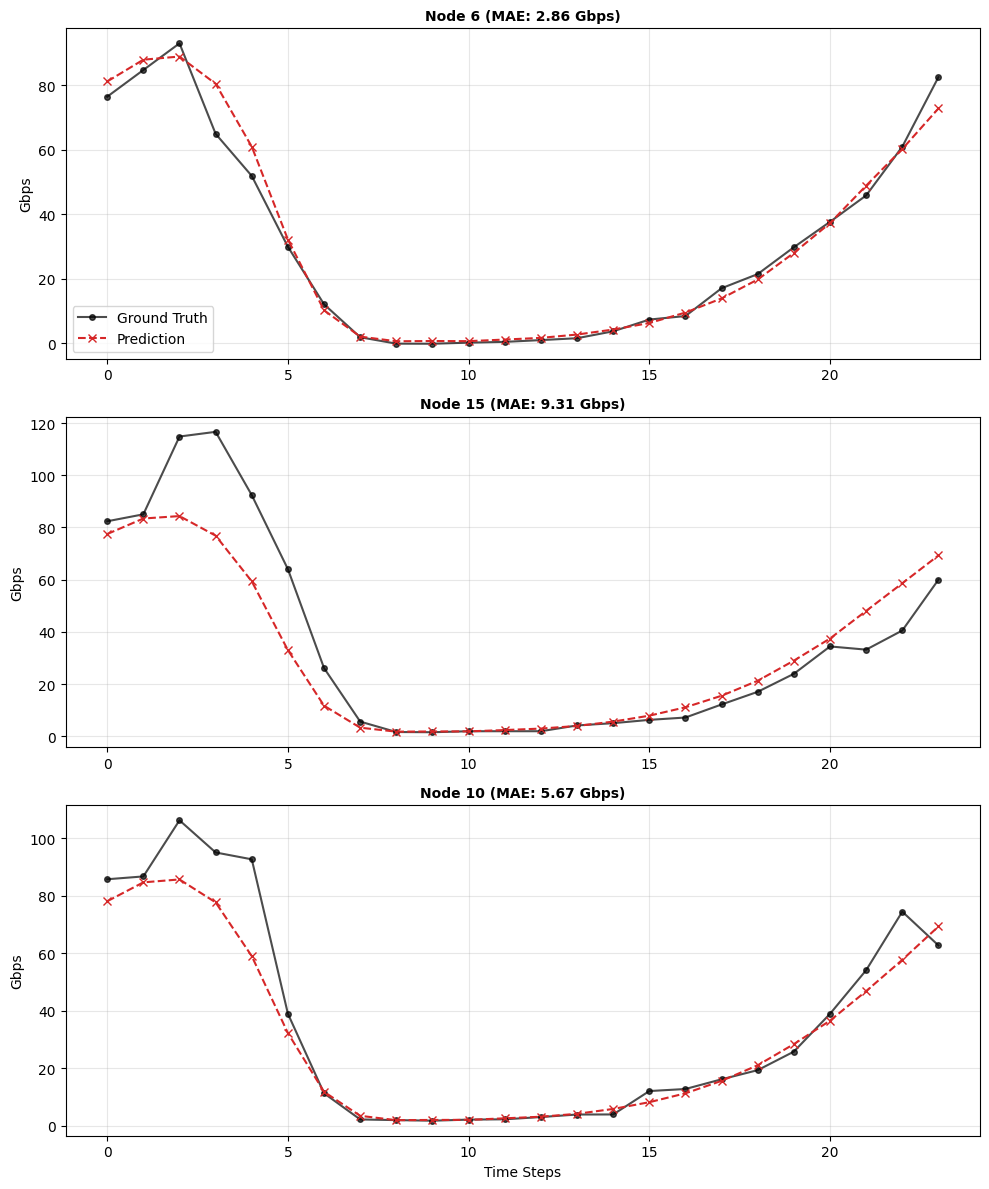

In [194]:
MODEL = GMAN(
        NODE_VECTORS,
        config
)

print(f"Retrieving model from {SAVE_PATH_0}")
state_dict = torch.load(SAVE_PATH_0)
MODEL.load_state_dict(state_dict)

validate_model(MODEL, TSS_VAL_DL, 'cpu', scaler_mean=TRAIN_MEAN, scaler_std=TRAIN_STD)
plot_random_batch_prediction(MODEL, TSS_VAL_DL, 'cpu', scaler_mean=TRAIN_MEAN, scaler_std=TRAIN_STD)

### MODEL ATT MASK

✅ Spatial Mask Enabled.
Retrieving model from GMAN_model_att_spatial.pth
📉 Starting Validation on 25 batches...

✅ Validation Complete:
   > MSE:  509.4255
   > RMSE: 22.5705 (Gbps)
   > MAE:  12.8162 (Gbps)
🎲 Visualizing Batch #23...
ℹ️ Multi-feature output detected (32, 24, 16, 16). Plotting Feature 0.


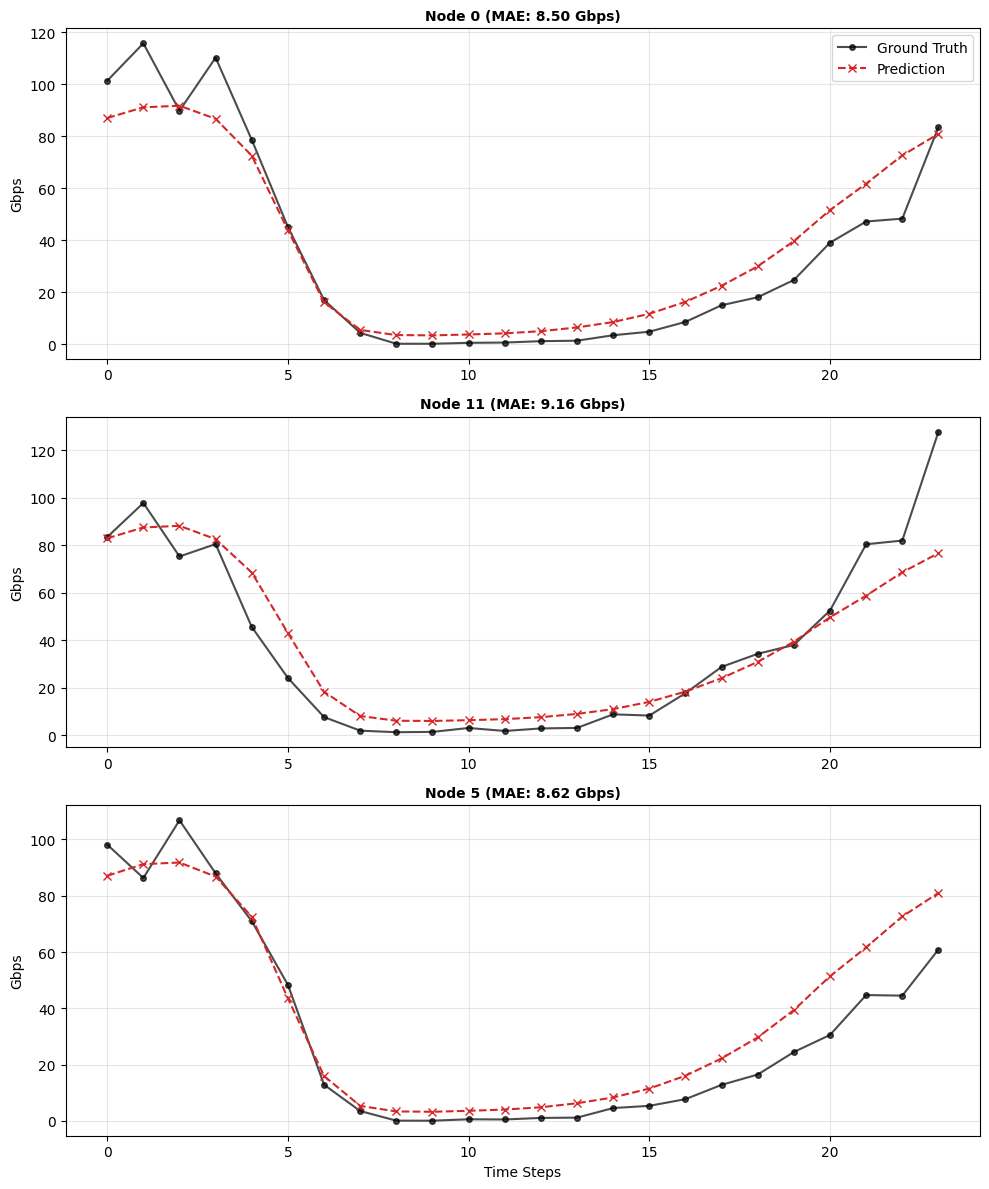

In [193]:
MODEL = GMAN(
        NODE_VECTORS,
        config,
        adj_att_mask=SPATIAL_MASK
)

print(f"Retrieving model from {SAVE_PATH_1}")
state_dict = torch.load(SAVE_PATH_1)
MODEL.load_state_dict(state_dict)

validate_model(MODEL, TSS_VAL_DL, 'cpu', scaler_mean=TRAIN_MEAN, scaler_std=TRAIN_STD)
plot_random_batch_prediction(MODEL, TSS_VAL_DL, 'cpu', scaler_mean=TRAIN_MEAN, scaler_std=TRAIN_STD)

# PHYSICAL RESTRICTIONS

ℹ️ Spatial Mask Disabled.
Retrieving model from GMAN_model_phy_loss.pth
📉 Starting Validation on 25 batches...

✅ Validation Complete:
   > MSE:  395.6760
   > RMSE: 19.8916 (Gbps)
   > MAE:  10.2113 (Gbps)
🎲 Visualizing Batch #15...
ℹ️ Multi-feature output detected (32, 24, 16, 16). Plotting Feature 0.


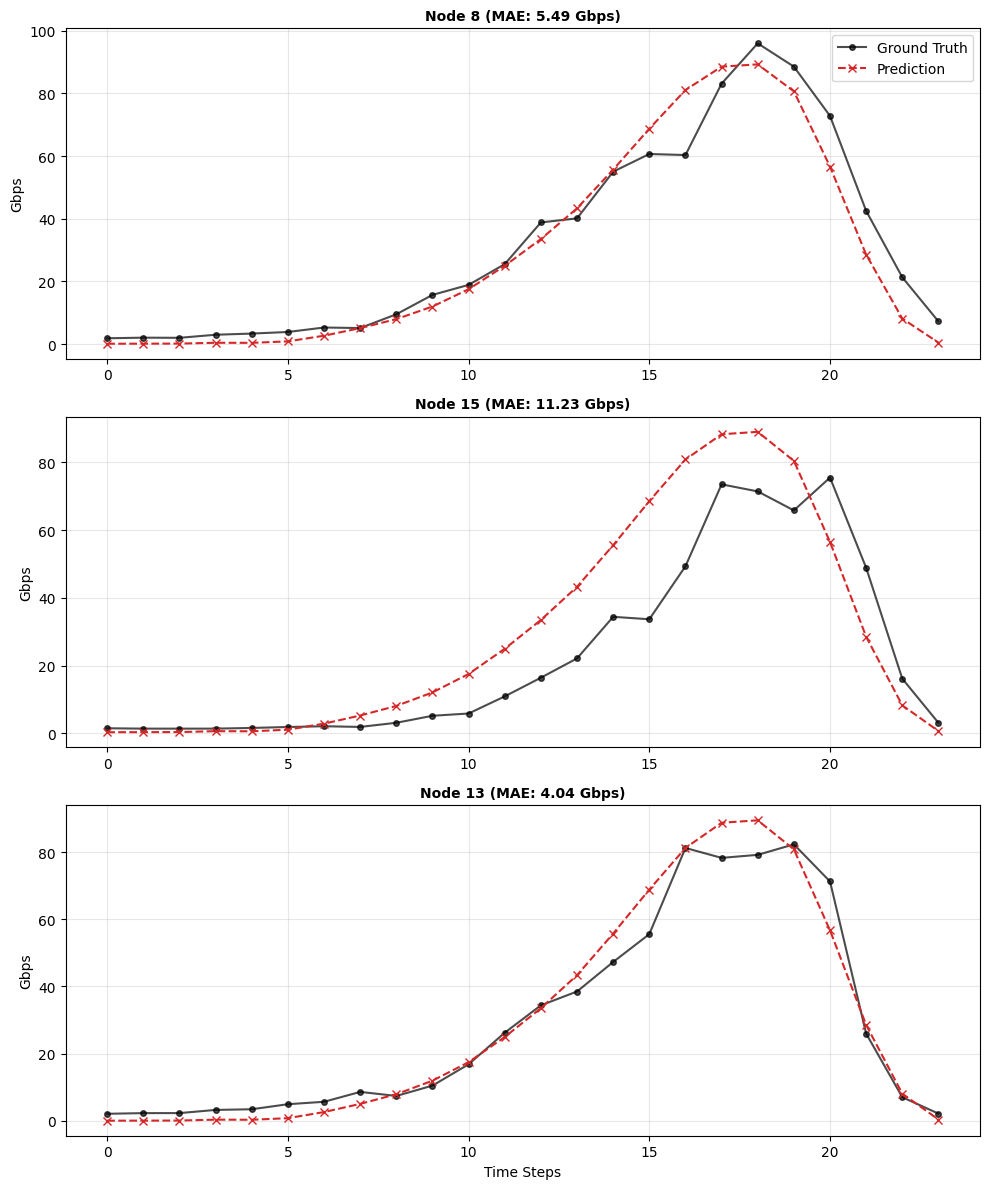

In [259]:
MODEL = GMAN(
        NODE_VECTORS,
        config
)

print(f"Retrieving model from {SAVE_PATH_2}")
state_dict = torch.load(SAVE_PATH_2)
MODEL.load_state_dict(state_dict)

validate_model(MODEL, TSS_VAL_DL, 'cpu', scaler_mean=TRAIN_MEAN, scaler_std=TRAIN_STD)
plot_random_batch_prediction(MODEL, TSS_VAL_DL, 'cpu', scaler_mean=TRAIN_MEAN, scaler_std=TRAIN_STD)

# PREDICTION

In [114]:
def prediction(model, data:pd.DataFrame, dataset_obj,hist_steps, pred_steps, device='cpu'):

    model.eval()
    model.to(device)
    _dates_pred = pd.date_range(start=data.index[-1] + pd.Timedelta(hours=1), periods=PRED_STEPS, freq='h')
    
    _pred_ds = NetworkTrafficDataset(
                    dataframe=data, 
                    num_his=hist_steps, 
                    num_pred=pred_steps, 
                    time_slot_hours=FREQ_H,
                    mean=dataset_obj.mean,
                    std=dataset_obj.std,
                    is_inference=False
                )

    _pred_dl = DataLoader(_pred_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    with torch.no_grad():
        
        for X, TE,Y in _pred_dl:
            pass

        X = X[-1:].to(device)
        X_masked = X.clone()
        X_masked[:, :, ~LEAF_MASK, :] = 0.0
        TE = TE[-1:].to(device)
        
        _pred = model(X_masked, TE)
    
    _pred = dataset_obj.reverse_transform(_pred)

    _pred_df = pd.DataFrame(_pred[-1].squeeze(-1), index=_dates_pred, columns=data.columns)

    return _pred_df

MODEL = GMAN(
        NODE_VECTORS,
        config
)

print(f"Retrieving model from {SAVE_PATH}")
state_dict = torch.load(SAVE_PATH, map_location=device)
MODEL.load_state_dict(state_dict)

PRED_DATA = DATA_RAW_MODEL.copy()
last_timestamp = PRED_DATA.index[-1]

print(f"the last timestamp is {last_timestamp}")
DAYS_PREDICT = 30

for _ in range(DAYS_PREDICT):

    print(f"Predicting day {_}")
    PRED_DATA = pd.concat([
        PRED_DATA, 
        prediction(MODEL, PRED_DATA, TSS_TRAIN_DS, HIST_STEPS, PRED_STEPS)
        ], axis=0)

PRED_DATA = PRED_DATA[PRED_DATA.index > last_timestamp]


Retrieving model from timeseries_GMAN_model_flow_loss_v4.pth
the last timestamp is 2024-06-28 23:00:00
Predicting day 0
Predicting day 1
Predicting day 2
Predicting day 3
Predicting day 4
Predicting day 5
Predicting day 6
Predicting day 7
Predicting day 8
Predicting day 9
Predicting day 10
Predicting day 11
Predicting day 12
Predicting day 13
Predicting day 14
Predicting day 15
Predicting day 16
Predicting day 17
Predicting day 18
Predicting day 19
Predicting day 20
Predicting day 21
Predicting day 22
Predicting day 23
Predicting day 24
Predicting day 25
Predicting day 26
Predicting day 27
Predicting day 28
Predicting day 29


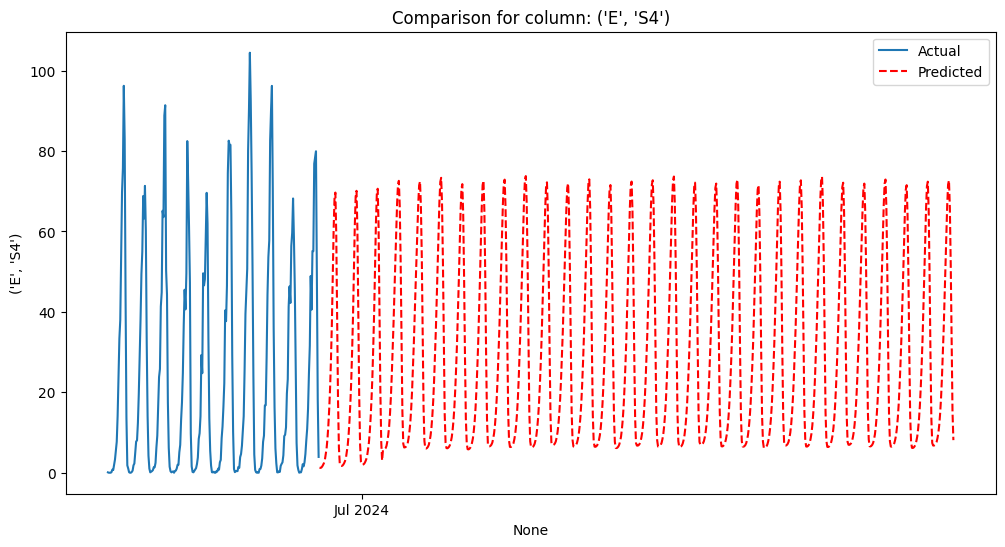

In [115]:
import random
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

column = random.choice(PRED_DATA.columns)

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(x=DATA_RAW_MODEL.iloc[-HIST_STEPS*5:][column].index, y=DATA_RAW_MODEL.iloc[-HIST_STEPS*5:][column], label='Actual', ax=ax)
sns.lineplot(x=PRED_DATA.index, y=PRED_DATA[column], label='Predicted', color='red', linestyle='--', ax=ax)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))


plt.title(f"Comparison for column: {column}")
plt.legend()    
plt.show()

## SPLITTER

In [130]:


class FlowNetworkConverter:
    def __init__(self, incidence_matrix, epsilon=1e-12):
        """
        Args:
            incidence_matrix (np.array): Shape (Nodes, Edges)
                                         -1 = Source (Leaving Node)
                                          1 = Target (Entering Node)
            epsilon (float): Small value to prevent division by zero.
        """
        self.B = incidence_matrix
        self.epsilon = epsilon
        
        # Pre-compute masks for efficiency
        # B_out: 1.0 where edge LEAVES node (Source), 0.0 otherwise
        self.B_out = (np.abs(self.B) - self.B) / 2.0
        
        # B_in: 1.0 where edge ENTERS node (Target), 0.0 otherwise
        self.B_in = (np.abs(self.B) + self.B) / 2.0
        
        # Pre-compute Topology Map (Edges -> Edges)
        # Maps input edges to output edges via nodes: (Edges, Nodes) @ (Nodes, Edges)
        self.topology_map = self.B_out.T @ self.B_in

    def flow_to_percentages(self, edge_flows):
        """
        Converts absolute flows into percentage splitters.
        
        Args:
            edge_flows: (..., Edges) array of absolute flow values.
            
        Returns:
            split_percentages: (..., Edges) array, normalized 0-1 per source node.
        """
        # 1. Calculate Total Outflow per Node
        # (..., Edges) @ (Edges, Nodes) -> (..., Nodes)
        # Note: B_out.T is (Edges, Nodes)
        node_outflows = edge_flows @ self.B_out.T
        
        # 2. Map Node Totals back to Edges (Broadcast)
        # (..., Nodes) @ (Nodes, Edges) -> (..., Edges)
        edge_denominators = node_outflows @ self.B_out
        
        # 3. Normalize (Element-wise Division)
        split_percentages = edge_flows / (edge_denominators + self.epsilon)
        
        # Handle strict 0/0 cases resulting in NaN (if epsilon didn't catch it)
        return np.nan_to_num(split_percentages)

    def percentages_to_flow(self, split_percentages, source_inflows):
        """
        Reconstructs absolute flows from splitters and source inflows.
        Solving: (I - M) * f = forced_flow
        
        Args:
            split_percentages: (..., Edges) Split ratios (0.0 to 1.0).
            source_inflows:    (..., Nodes) External flow entering nodes.
            
        Returns:
            reconstructed_flows: (..., Edges) Absolute flow values.
        """
        # Get dimensions
        *batch_dims, n_edges = split_percentages.shape
        
        # 1. Create Diagonal Percentage Matrix P
        # Expands (..., Edges) -> (..., Edges, Edges) diagonal matrices
        P = np.apply_along_axis(np.diag, -1, split_percentages)

        # 2. Compute Transition Matrix M
        # M = P @ (B_out.T @ B_in)
        # This maps "Flow from Input Edge" -> "Flow to Output Edge"
        M = P @ self.topology_map

        # 3. Compute Forced Flow (From External Sources)
        # F_forced = P @ B_out.T @ Source_Inflows
        # Reshape sources to column vector: (..., Nodes) -> (..., Nodes, 1)
        S_vec = source_inflows[..., np.newaxis]
        
        # (Edges, Nodes) @ (..., Nodes, 1) -> (..., Edges, 1)
        source_to_edges = np.matmul(self.B_out.T, S_vec)
        
        # Apply percentages to the source flow
        forced_flow = P @ source_to_edges

        # 4. Solve Linear System (I - M)x = forced_flow
        # Identity matrix (Edges, Edges)
        I = np.eye(n_edges)
        
        # A = I - M. Broadcasting handles the batch dims automatically.
        A = I - M
        
        # Solve Ax = b
        flows = np.linalg.solve(A, forced_flow)

        return flows.squeeze(-1)




class FlowNetworkConverter:
    def __init__(self, incidence_matrix, epsilon=1e-12):
        """
        Args:
            incidence_matrix (np.array): Shape (Nodes, Edges)
            epsilon (float): Small value to prevent division by zero.
        """
        self.B = incidence_matrix
        self.epsilon = epsilon
        
        # Pre-compute masks
        # B_out: 1.0 where edge LEAVES node
        self.B_out = (np.abs(self.B) - self.B) / 2.0
        
        # B_in: 1.0 where edge ENTERS node
        self.B_in = (np.abs(self.B) + self.B) / 2.0
        
        # Topology Map: Maps input edges to output edges via nodes
        self.topology_map = self.B_out.T @ self.B_in

    def flow_to_percentages(self, edge_flows, source_inflows=None):
        """
        Converts flows to splitters AND calculates node losses (imbalance).
        
        Args:
            edge_flows: (..., Edges) Absolute flow on edges.
            source_inflows: (..., Nodes) External flow entering nodes. 
                            If None, assumes 0 external inflow.
            
        Returns:
            split_percentages: (..., Edges) Normalized split ratios (0-1).
            node_losses:       (..., Nodes) Flow lost at each node.
                               Positive = Loss (Leak). Negative = Gain (Generation).
                               Formula: Loss = (Inflow_Edges + Source) - Outflow_Edges
        """
        # Handle default source_inflows (zeros)
        if source_inflows is None:
            source_shape = edge_flows.shape[:-1] + (self.B.shape[0],)
            source_inflows = np.zeros(source_shape)

        # 1. Calculate Outflow per Node (from Edges)
        node_outflows = edge_flows @ self.B_out.T
        
        # 2. Calculate Inflow per Node (from Edges)
        node_inflows_internal = edge_flows @ self.B_in.T
        
        # 3. Calculate Split Percentages
        # Denominator is the total flow LEAVING the node to the network
        edge_denominators = node_outflows @ self.B_out
        split_percentages = edge_flows / (edge_denominators + self.epsilon)
        split_percentages = np.nan_to_num(split_percentages)

        # 4. Calculate Loss / Imbalance
        # Balance Equation: In_Internal + Source = Out_Internal + Loss
        # Therefore: Loss = (In_Internal + Source) - Out_Internal
        total_node_inflow = node_inflows_internal + source_inflows
        node_losses = total_node_inflow - node_outflows
        
        return split_percentages, node_losses

    def percentages_to_flow(self, split_percentages, source_inflows, node_losses=None):
        """
        Reconstructs flows using splitters, sources, AND losses.
        
        Args:
            split_percentages: (..., Edges) Split ratios.
            source_inflows:    (..., Nodes) External inflow.
            node_losses:       (..., Nodes) Flow loss. (Optional, defaults to 0).
            
        Returns:
            reconstructed_flows: (..., Edges)
        """
        *batch_dims, n_edges = split_percentages.shape
        n_nodes = source_inflows.shape[-1]
        
        # Handle default losses (zeros)
        if node_losses is None:
            node_losses = np.zeros_like(source_inflows)

        # 1. Create Diagonal Percentage Matrix P
        P = np.apply_along_axis(np.diag, -1, split_percentages)

        # 2. Compute Transition Matrix M
        M = P @ self.topology_map

        # 3. Compute Net Flow Driving the Edges
        # The flow available to be pushed into edges is: (Source - Loss)
        # If Loss is positive, it reduces the available flow.
        net_node_injection = source_inflows - node_losses
        
        # Reshape to column vector: (..., Nodes, 1)
        net_injection_vec = net_node_injection[..., np.newaxis]
        
        # Map injection to edges: (Edges, Nodes) @ (Nodes, 1)
        injection_to_edges = np.matmul(self.B_out.T, net_injection_vec)
        
        # Apply percentages to the injection
        forced_flow = P @ injection_to_edges

        # 4. Solve Linear System (I - M)x = forced_flow
        I = np.eye(n_edges)
        A = I - M
        flows = np.linalg.solve(A, forced_flow)

        return flows.squeeze(-1)

import numpy as np

class LineGraphConverter:
    def __init__(self, adjacency_matrix, epsilon=1e-12):
        """
        Args:
            adjacency_matrix (np.array): Shape (Edges, Edges)
                                         A[j, i] = 1 if Edge i feeds Edge j.
                                         (Column is Source, Row is Target)
            epsilon (float): Small value to prevent division by zero.
        """
        self.A = adjacency_matrix
        self.epsilon = epsilon

    def flow_to_percentages(self, flows):
        """
        Converts flows to splitters based on Edge-to-Edge grouping.
        
        Args:
            flows: (..., Edges) Absolute flow values.
            
        Returns:
            transition_matrix: (..., Edges, Edges) 
                               Weighted adjacency matrix where columns sum to 1.
                               M[j, i] = % of Edge i's flow that goes to Edge j.
            imbalance:         (..., Edges) Difference between Parent Flow and Sum(Children).
        """
        # 1. Identify "Child Groups" (Who shares the same parent?)
        # We need to know the total flow of all children fed by edge i.
        # This requires broadcasting the flows against the adjacency map.
        
        # Expand flows for broadcasting: (..., 1, Edges)
        # This represents "Potential Source Flow" from every edge i
        source_flows = flows[..., np.newaxis, :] 
        
        # Mask: We only care about flows where A[j, i] is 1 (Valid connections)
        # We need the flow of the TARGETS (j) to calculate the split.
        target_flows = flows[..., :, np.newaxis] # (..., Edges, 1) -> Represents j
        
        # But we need to sum over the 'j' dimension (rows) for every 'i' (column)
        # To get the denominator for Edge i: Sum of flows of all j where A[j,i]=1
        
        # Filter flows through Adjacency to get only connected children
        # (..., Edges) @ (Edges, Edges) is not quite right because flows are values, not maps.
        
        # Correct approach:
        # Denominator for Edge i = Sum(Flow_j) for all j where A[j,i] = 1
        # Mathematically: Denominators = A.T @ Flows
        
        # Transpose A so rows=sources, cols=targets. 
        # Then multiply by flows to sum the targets.
        children_total_flow = flows @ self.A  # Shape (..., Edges)
        
        # 2. Calculate Split Weights
        # We need a weighted matrix M where M[j,i] = Flow_j / Total_Children_of_i
        
        # Reshape for broadcasting (..., 1, Edges)
        denominators = children_total_flow[..., np.newaxis, :]
        
        # We want to weight the adjacency matrix A itself.
        # Flow_j must be broadcast along the rows.
        target_flows_matrix = flows[..., :, np.newaxis] 
        
        # Calculation:
        # M[j,i] = A[j,i] * (Flow_j / Denominator_i)
        
        # Avoid division by zero
        safe_denominators = denominators + self.epsilon
        
        # Ratio matrix: (Flow_j / Sum_Sibling_Flows)
        # We broadcast Flow_j (rows) against Denom_i (cols)
        ratios = target_flows_matrix / safe_denominators
        
        # Apply mask A so we only keep valid connections
        weighted_adjacency = self.A * ratios
        
        # 3. Calculate Imbalance (Parent Flow vs Children Total)
        # Does Edge i have as much flow as the sum of Edges j, k, l?
        imbalance = flows - children_total_flow
        
        return weighted_adjacency, imbalance

    def percentages_to_flow(self, transition_matrix, source_inflows, losses=None):
        """
        Args:
            transition_matrix: (..., Edges, Edges) The weighted Adjacency M.
            source_inflows:    (..., Edges) Flow injected directly into specific edges.
            losses:            (..., Edges) Flow lost at the junction (Optional).
        """
        *batch, n_edges = source_inflows.shape
        if losses is None:
            losses = np.zeros_like(source_inflows)
            
        # 1. Setup the Linear System
        # f = M @ f + (Source - Loss)
        # (I - M) @ f = Net_Source
        
        I = np.eye(n_edges)
        A_sys = I - transition_matrix
        
        net_source = source_inflows - losses
        
        # We need net_source as a column vector (..., Edges, 1)
        b = net_source[..., np.newaxis]
        
        # 2. Solve
        flows = np.linalg.solve(A_sys, b)
        
        return flows.squeeze(-1)

SOURCE_NODES = [x for x in NODES if (INC_MATRIX_DF == 1).loc[x].sum() == 0]
SINK_NODES = [x for x in NODES if (INC_MATRIX_DF == -1).loc[x].sum() == 0]
SINK_NODES


['S7', 'S6', 'S5', 'S1', 'S2', 'S3', 'S4']

In [150]:
INC_MATRIX_DF_AUG =INC_MATRIX_DF.copy()

for i in range(1, 7):
    node = f"S{i}"
    print(node)
    col_name = pd.MultiIndex.from_tuples([(node,'OUTPUT')])
    INC_MATRIX_DF_AUG[col_name] = 0
    INC_MATRIX_DF_AUG.loc[node, col_name] = -1

INC_MATRIX_DF_AUG

S1
S2
S3
S4
S5
S6


HR_A MR_A    C      HR_B MR_B         A            ...    D    E    B  \
     MR_A    C    D   S7 MR_B MR_A    A    B   S1   S2  ...   S5   S4    D   
HR_A -1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
MR_A  1.0 -1.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
C     0.0  1.0 -1.0 -1.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
HR_B  0.0  0.0  0.0  0.0 -1.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
MR_B  0.0  0.0  0.0  0.0  1.0 -1.0 -1.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
A     0.0  0.0  0.0  0.0  0.0  0.0  1.0 -1.0 -1.0 -1.0  ...  0.0  0.0  0.0   
D     0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ... -1.0  0.0  1.0   
S7    0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
E     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0 -1.0  0.0   
S6    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
S5    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  1.0  0.0  0.0   
B     0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  ...  0.0  0.0 -1.0   
S1    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  ...  0.0  0.0  0.0   
S2    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  ...  0.0  0.0  0.0   
S3    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
S4    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  1.0  0.0   

              S1     S2     S3     S4     S5     S6  
       S3 OUTPUT OUTPUT OUTPUT OUTPUT OUTPUT OUTPUT  
HR_A  0.0      0      0      0      0      0      0  
MR_A  0.0      0      0      0      0      0      0  
C     0.0      0      0      0      0      0      0  
HR_B  0.0      0      0      0      0      0      0  
MR_B  0.0      0      0      0      0      0      0  
A     0.0      0      0      0      0      0      0  
D     0.0      0      0      0      0      0      0  
S7    0.0      0      0      0      0      0      0  
E     0.0      0      0      0      0      0      0  
S6    0.0      0      0      0      0      0     -1  
S5    0.0      0      0      0      0     -1      0  
B    -1.0      0      0      0      0      0      0  
S1    0.0     -1      0      0      0      0      0  
S2    0.0      0     -1      0      0      0      0  
S3    1.0      0      0     -1      0      0      0  
S4    0.0      0      0      0     -1      0      0  

[16 rows x 22 columns]

In [178]:
INC_MATRIX_DF*(-1)

HR_A MR_A    C      HR_B MR_B         A              D              E  \
     MR_A    C    D   S7 MR_B MR_A    A    B   S1   S2    E   S6   S5   S4   
HR_A  1.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0   
MR_A -1.0  1.0 -0.0 -0.0 -0.0 -1.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0   
C    -0.0 -1.0  1.0  1.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0   
HR_B -0.0 -0.0 -0.0 -0.0  1.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0   
MR_B -0.0 -0.0 -0.0 -0.0 -1.0  1.0  1.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0   
A    -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -1.0  1.0  1.0  1.0 -0.0 -0.0 -0.0 -0.0   
D    -0.0 -0.0 -1.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0  1.0  1.0  1.0 -0.0   
S7   -0.0 -0.0 -0.0 -1.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0   
E    -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -1.0 -0.0 -0.0  1.0   
S6   -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -1.0 -0.0 -0.0   
S5   -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -1.0 -0.0   
B    -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -1.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0   
S1   -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -1.0 -0.0 -0.0 -0.0 -0.0 -0.0   
S2   -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -1.0 -0.0 -0.0 -0.0 -0.0   
S3   -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0   
S4   -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -0.0 -1.0   

        B       
        D   S3  
HR_A -0.0 -0.0  
MR_A -0.0 -0.0  
C    -0.0 -0.0  
HR_B -0.0 -0.0  
MR_B -0.0 -0.0  
A    -0.0 -0.0  
D    -1.0 -0.0  
S7   -0.0 -0.0  
E    -0.0 -0.0  
S6   -0.0 -0.0  
S5   -0.0 -0.0  
B     1.0  1.0  
S1   -0.0 -0.0  
S2   -0.0 -0.0  
S3   -0.0 -1.0  
S4   -0.0 -0.0

In [188]:
SPLITTER = FlowNetworkConverter((-1*INC_MATRIX_DF).values)
SPLITTER

In [190]:
_rand_sample = DATA_RAW_MODEL.sample(1)
_rand_sample

from                   HR_A   MR_A      C           HR_B   MR_B          \
to                     MR_A      C      D     S7    MR_B   MR_A       A   
2024-01-15 19:00:00  121.78  167.3  121.1  73.45  387.57  91.19  281.53   

from                      A                    D                   E       B  \
to                        B     S1     S2      E     S6     S5    S4       D   
2024-01-15 19:00:00  192.21  60.01  94.35  65.03  92.05  84.69  53.2  116.65   

from                        
to                      S3  
2024-01-15 19:00:00  54.06

In [191]:
_splited, _losses = SPLITTER.flow_to_percentages(_rand_sample.values)
display(pd.DataFrame(_splited, columns=EDGES))
display(pd.DataFrame(_losses, columns=EDGES))


,"(HR_A, MR_A)","(MR_A, C)","(C, D)","(C, S7)","(HR_B, MR_B)","(MR_B, MR_A)","(MR_B, A)","(A, B)","(A, S1)","(A, S2)","(D, E)","(D, S6)","(D, S5)","(E, S4)","(B, D)","(B, S3)"
0,0.571818,1.0,0.509359,1.0,1.0,0.428182,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.490641,1.0


,"(HR_A, MR_A)","(MR_A, C)","(C, D)","(C, S7)","(HR_B, MR_B)","(MR_B, MR_A)","(MR_B, A)","(A, B)","(A, S1)","(A, S2)","(D, E)","(D, S6)","(D, S5)","(E, S4)","(B, D)","(B, S3)"
0,121.78,-45.67,27.25,387.57,-14.85,65.04,4.02,-73.45,-11.83,-92.05,-84.69,-21.5,-60.01,-94.35,-54.06,-53.2


In [192]:
_source_inflows = _rand_sample.copy()
_source_inflows.loc[:, ~_source_inflows.columns.get_level_values(0).isin(SOURCE_NODES)] = 0
_source_inflows

from                   HR_A MR_A    C         HR_B MR_B         A            \
to                     MR_A    C    D   S7    MR_B MR_A    A    B   S1   S2   
2024-01-15 19:00:00  121.78  0.0  0.0  0.0  387.57  0.0  0.0  0.0  0.0  0.0   

from                   D              E    B       
to                     E   S6   S5   S4    D   S3  
2024-01-15 19:00:00  0.0  0.0  0.0  0.0  0.0  0.0

In [193]:
SPLITTER.percentages_to_flow(_splited, _source_inflows.values, _losses)

array([[121.78, 167.3 , 121.1 ,  73.45, 775.14,  91.19, 281.53, 192.21,
         60.01,  94.35,  65.03,  92.05,  84.69,  53.2 , 116.65,  54.06]])

In [194]:
_rand_sample

from                   HR_A   MR_A      C           HR_B   MR_B          \
to                     MR_A      C      D     S7    MR_B   MR_A       A   
2024-01-15 19:00:00  121.78  167.3  121.1  73.45  387.57  91.19  281.53   

from                      A                    D                   E       B  \
to                        B     S1     S2      E     S6     S5    S4       D   
2024-01-15 19:00:00  192.21  60.01  94.35  65.03  92.05  84.69  53.2  116.65   

from                        
to                      S3  
2024-01-15 19:00:00  54.06

In [ ]:
df.loc[:, ~df.columns.isin(SOURCE_NODES)]


array([[ 63.53      , 129.43485911,  45.8219895 ,  83.61286961,
          0.        ,  65.90485911, 287.85514089, 169.4002449 ,
         63.98327519,  54.47162079,  37.61678568,  52.83608012,
         39.63654252,  37.61678568,  84.26741881,  85.13282609]])

In [22]:
_rand_sample.loc[:,:] = 0

In [24]:
_rand_sample.loc[:,('HR_A','MR_A')] = 74.08
_rand_sample.loc[:,('HR_B','MR_B')] = 382.42

In [19]:
_splited = SPLITTER.flow_to_percentages(_rand_sample.values)
pd.DataFrame(_splited, columns=EDGES)

,"(HR_A, MR_A)","(MR_A, C)","(C, D)","(C, S7)","(HR_B, MR_B)","(MR_B, MR_A)","(MR_B, A)","(A, B)","(A, S1)","(A, S2)","(D, E)","(D, S6)","(D, S5)","(E, S4)","(B, D)","(B, S3)"
0,1.0,1.0,0.591446,0.408554,1.0,0.242025,0.757975,0.591736,0.177999,0.230265,0.43574,0.283172,0.281088,1.0,0.514494,0.485506


In [ ]:
False,  True, False, False, False,  True,  True, False, False, True,  True,  True,  True,  True, False,  True

In [109]:
_rand_sample

from                  HR_A    MR_A      C           HR_B   MR_B         \
to                    MR_A       C      D     S7    MR_B   MR_A      A   
2024-02-11 14:00:00  52.09  111.01  59.04  45.46  311.97  47.64  228.5   

from                      A                    D                    E      B  \
to                        B     S1     S2      E     S6     S5     S4      D   
2024-02-11 14:00:00  102.52  47.75  72.33  46.91  47.02  50.33  43.88  73.96   

from                        
to                      S3  
2024-02-11 14:00:00  51.36

In [108]:
SPLITTER.percentages_to_flow(_splited, np.array([52.09,0,0,0,311.97,0,0,0,0,0,0,0,0,0,0,0]))

array([[ 52.09      , 128.50916426,  99.05914745,  29.45001681,
          0.        ,  76.41916427, 235.55083573, 107.14291487,
         33.5332787 ,  94.87464217,  34.01189803,  89.66773116,
         64.93180532,  34.01189803,  89.55228705,  17.59062781]])

In [30]:
INC_MATRIX_DF.loc[INC_MATRIX_DF == 1].sum()

ValueError: Cannot index with multidimensional key

In [49]:
-1*INC_MATRIX_DF.values.T.dot(_rand_sample.values.T).reshape(1,-1)[0]>0


array([False,  True, False, False, False,  True,  True, False, False,
        True,  True,  True,  True,  True, False,  True])

In [56]:
_rand_sample

from                   HR_A    MR_A      C           HR_B   MR_B          \
to                     MR_A       C      D     S7    MR_B   MR_A       A   
2024-05-22 17:00:00  101.72  188.87  106.2  81.67  403.33  75.44  310.67   

from                      A                    D                    E      B  \
to                        B     S1     S2      E     S6     S5     S4      D   
2024-05-22 17:00:00  196.43  57.33  56.16  51.79  76.66  78.27  48.83  97.23   

from                        
to                      S3  
2024-05-22 17:00:00  55.73

In [58]:
B = INC_MATRIX_DF.values.T
_f = _rand_sample.values

def calculate_source_inflows(B, edge_flows):
        """
        Calculates external source inflows based on flow conservation violations.
        
        Args:
            edge_flows: (..., Edges) Absolute flow values.
            
        Returns:
            source_inflows: (..., Nodes) Positive values where external flow enters.
        """
        # 1. Compute Net Node Balance
        # Formula: x = B @ f
        # We perform (..., Edges) @ (Edges, Nodes). 
        # Note: We usually multiply B @ f, but since flows are last dim, 
        # we do flow @ B.T to match shapes.
        net_balance = edge_flows @ B.T
        return net_balance
        
        # 2. Extract Sources
        # If net_balance is NEGATIVE, it means flow is being generated there.
        # We want that magnitude as a positive number.
        # We ignore positive balance (Sinks) by using ReLU logic (max(0, -x)).
        source_inflows = np.maximum(0, -net_balance)
        
        return source_inflows

calculate_source_inflows(B,_f)

array([[  87.15,  -82.67,  204.47,   90.23,  321.66, -214.46, -327.89,
           1.22,    2.83,  -26.61, -253.34, -254.51, -258.88,   -1.6 ,
         234.01,   20.57]])

In [71]:
SOURCE_NODES = [x for x in NODES if (INC_MATRIX_DF == 1).loc[x].sum() == 0]
SOURCE_NODES

['HR_A', 'HR_B']

In [75]:
_rand_sample.loc[:, pd.IndexSlice[SOURCE_NODES, :]]

from,HR_A,HR_B
to,MR_A,MR_B
2024-05-22 17:00:00,101.72,403.33


In [ ]:
# --- 1. Setup Graph ---
# 3 Nodes, 4 Edges
# Node 0 (Source) -> Splits to e0, e1
# Node 1 (Transit) -> Receives e0, Sends e2
# Node 2 (Sink)    -> Receives e1, e2, Sends e3
B = np.array([
    [-1, -1,  0,  0],  # Node 0
    [ 1,  0, -1,  0],  # Node 1
    [ 0,  1,  1, -1]   # Node 2
])

converter = FlowNetworkConverter(B)

# --- 2. Create Dummy Data ---
# Batch=1, Time=2, Edges=4
# Flows represent a valid network state (conservation of mass satisfied)
# T0: Node 0 emits 100 -> 20 (e0) + 80 (e1)
# T1: Node 0 emits 100 -> 50 (e0) + 50 (e1)
original_flows = np.array([
    [[20.0, 80.0, 20.0, 100.0], 
     [50.0, 50.0, 50.0, 100.0]]
])

# Source Inflows corresponding to the above flows
# Only Node 0 has external inflow (100 units)
source_inflows = np.array([
    [[100.0, 0.0, 0.0],
     [100.0, 0.0, 0.0]]
])

# --- 3. Forward: Flow -> Splitters ---
splitters = converter.flow_to_percentages(original_flows)

print("--- Step 1: Computed Splitters ---")
print(f"T=0 (e0, e1): {splitters[0,0,0]:.2f}, {splitters[0,0,1]:.2f}") 
# Expected: 0.20, 0.80

# --- 4. Inverse: Splitters + Source -> Flow ---
reconstructed = converter.percentages_to_flow(splitters, source_inflows)

print("\n--- Step 2: Reconstruction Check ---")
print(f"Original (T=0):      {original_flows[0,0]}")
print(f"Reconstructed (T=0): {reconstructed[0,0]}")

# Verify accuracy
mse = np.mean((original_flows - reconstructed)**2)
print(f"\nReconstruction MSE: {mse:.20f}")